<a href="https://colab.research.google.com/github/aneharidouaeencg-del/AI/blob/main/Rapport_transport_marocain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



*   Anehari Douae
*   22007689
*   PSCM




# **Sujet : Prédiction du coût de transport optimal (routier, maritime, aérien) selon le profil d'expédition**

**PARTIE 1 : GÉNÉRATION ET ANALYSE DES DONNÉES DE TRANSPORT MAROCAIN**


🚛 ANALYSE DES COÛTS DE TRANSPORT MAROCAIN 2026

[ÉTAPE 1] Génération du dataset...
🚀 Génération de 10000 expéditions...
⚙️ Calcul des coûts de transport...
📊 Application des facteurs d'ajustement...
✅ Génération terminée !

[ÉTAPE 2] Aperçu des données:

Premières lignes:
    poids_kg  volume_m3  valeur_marchandise  distance_km mode_transport type_marchandise port_origine    destination  mois type_conteneur incoterm  volume_annuel_tonnes  cout_mad_kg  cout_mad_m3
0     689.13       2.51             3751.16          500        routier          general       Agadir     Europe_Sud     1         20_std      DDP                     0        0.855      235.176
1     335.01       0.94             2546.95         3000         aerien          general   Tanger-Med     Europe_Sud     2         20_std      DDP                  5000       11.106     3950.684
2  185949.90     761.20           812352.48         2000       maritime          general   Casablanca    Europe_Nord     5         20_std    

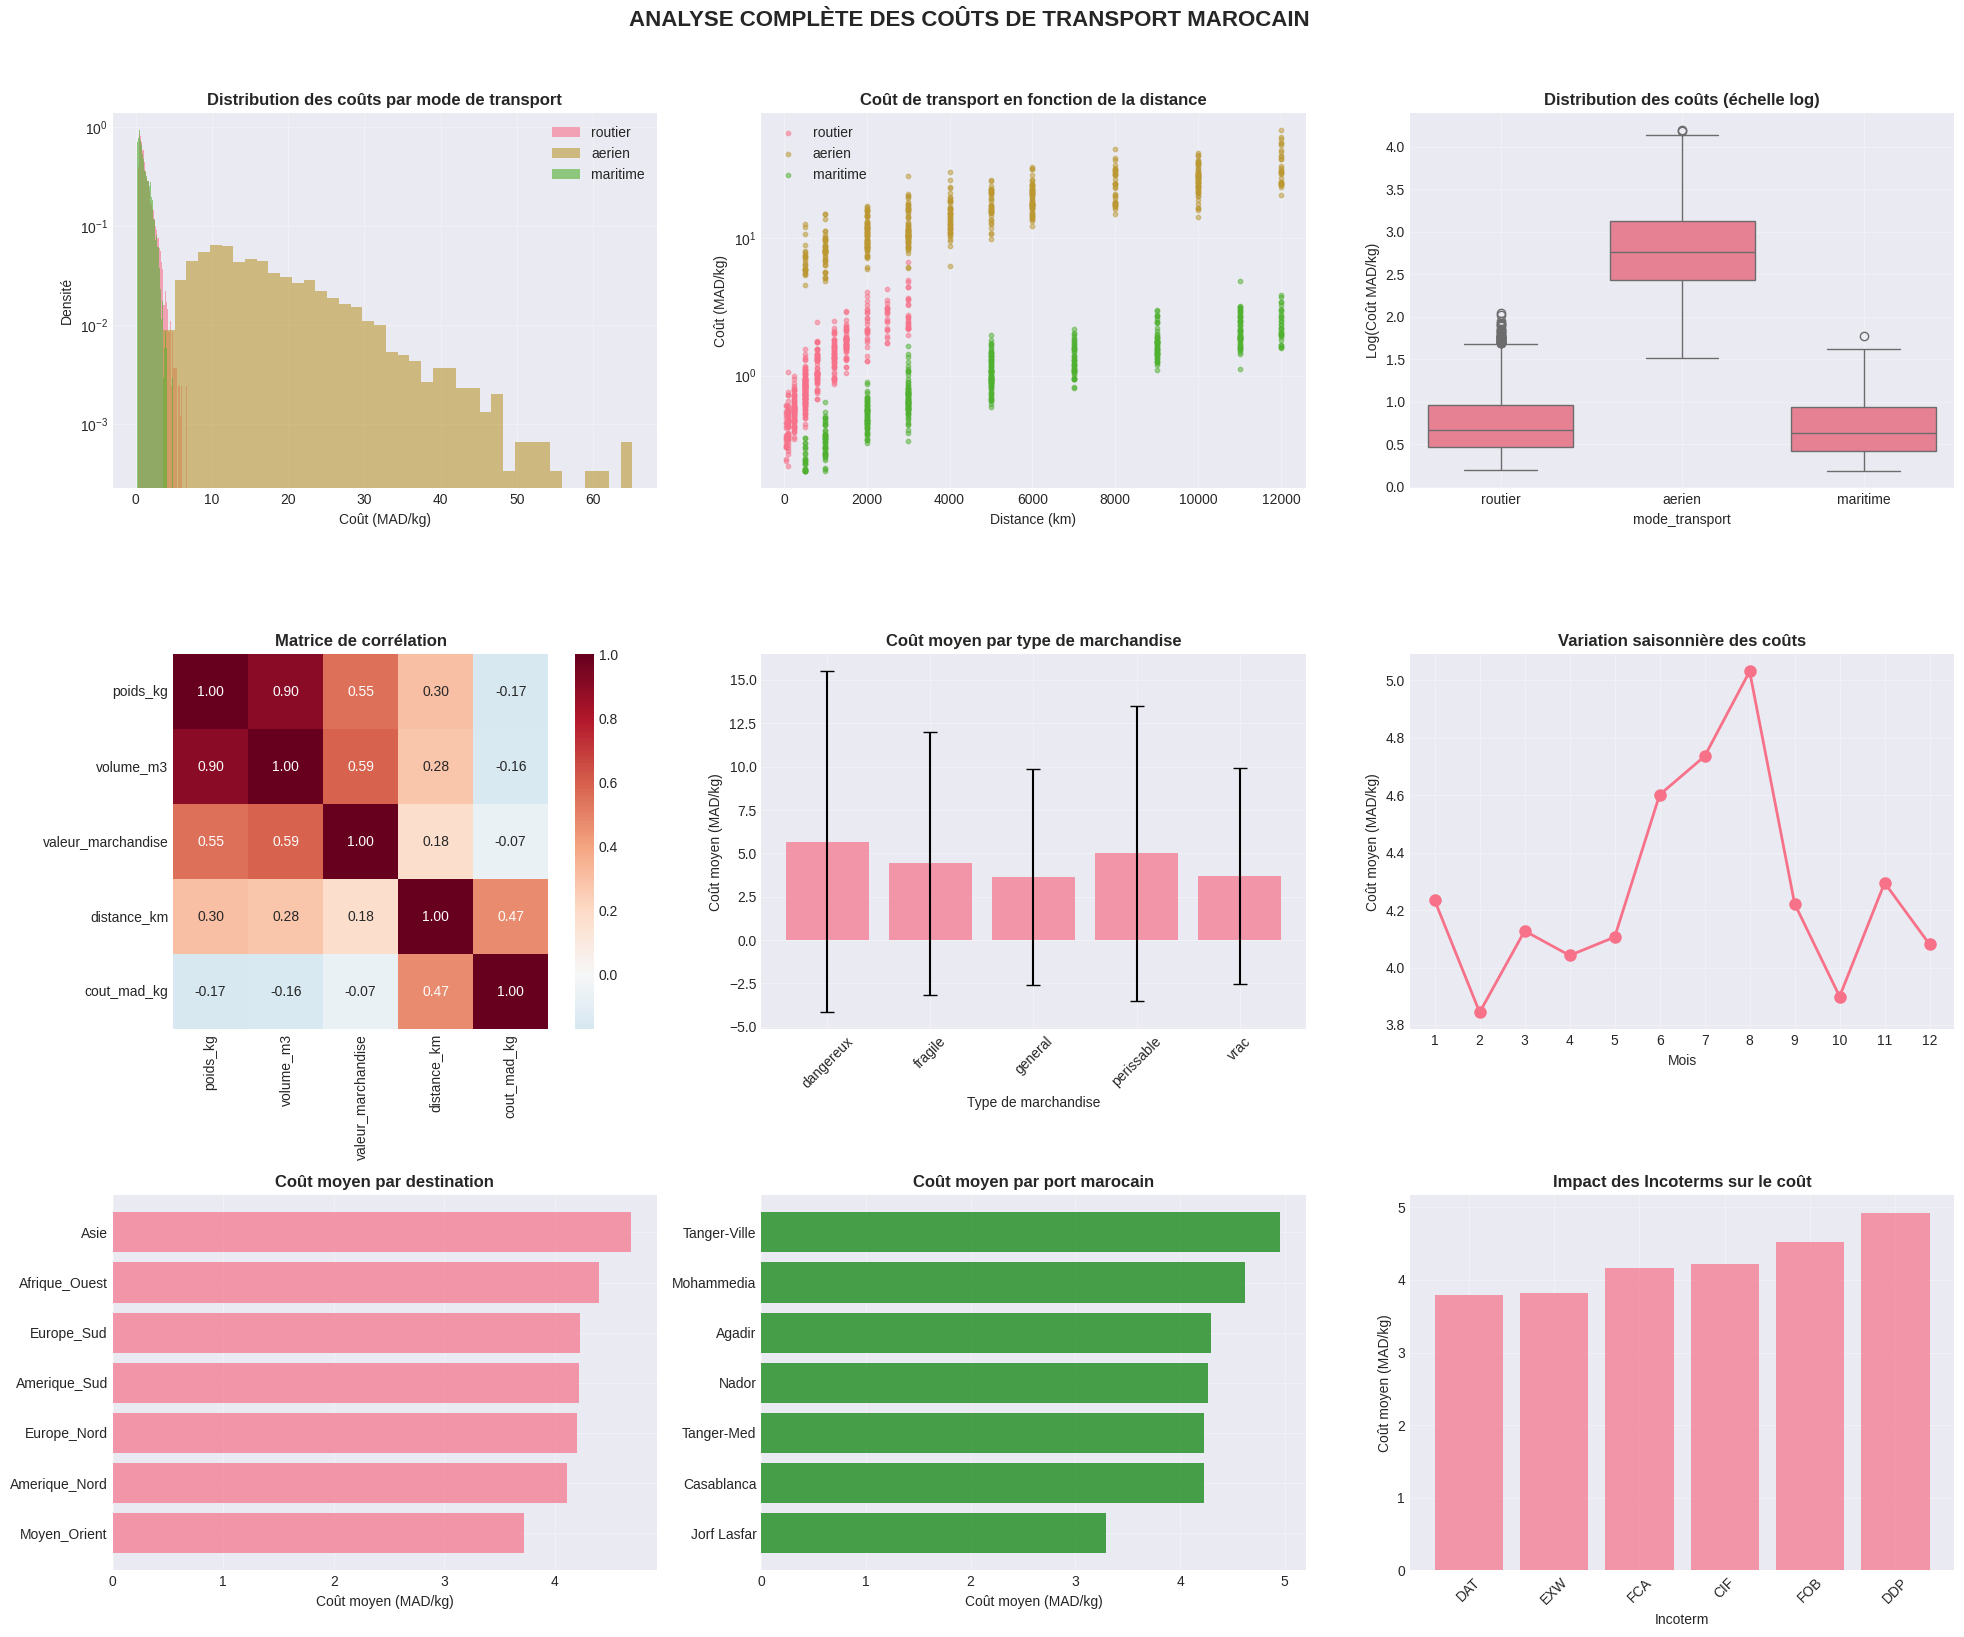


[ÉTAPE 6] Génération des statistiques détaillées...

📊 STATISTIQUES DÉTAILLÉES

📋 TABLEAU CROISÉ MODE × TYPE DE MARCHANDISE:
type_marchandise  dangereux  fragile  general  perissable  vrac    All
mode_transport                                                        
aerien                  194      384      778         403   203   1962
maritime                304      579     1205         587   287   2962
routier                 506      998     2034        1016   522   5076
All                    1004     1961     4017        2006  1012  10000

💰 TOP 10 DES EXPÉDITIONS LES PLUS CHÈRES (MAD/kg):
mode_transport type_marchandise  distance_km  poids_kg  cout_mad_kg
        aerien        dangereux        12000     40.96       65.160
        aerien        dangereux        12000   2064.32       64.691
        aerien       perissable        12000  10674.75       61.506
        aerien        dangereux        10000  21223.73       59.930
        aerien        dangereux        12000    255.37  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration pour des graphiques de qualité
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ------------------------------------------------------------
# 1. GÉNÉRATION DU DATASET AVEC CONTRAINTES RÉALISTES
# ------------------------------------------------------------

def creer_dataset_transport_marocain(n_echantillons=10000, random_seed=42):
    """
    Génère un dataset réaliste de coûts de transport pour le Maroc

    Paramètres:
    -----------
    n_echantillons : int, nombre d'expéditions à générer
    random_seed : int, seed pour la reproductibilité

    Retour:
    -------
    df : DataFrame avec les données générées
    """

    np.random.seed(random_seed)

    print(f"🚀 Génération de {n_echantillons} expéditions...")

    # --- 1.1 MODE DE TRANSPORT (distribution réaliste Maroc) ---
    # Source: AMDL/ANP - 50% routier, 30% maritime, 20% aérien
    mode_transport = np.random.choice(
        ['routier', 'maritime', 'aerien'],
        n_echantillons,
        p=[0.5, 0.3, 0.2]
    )

    # --- 1.2 DISTANCES RÉALISTES PAR MODE ---
    distance_km = np.zeros(n_echantillons)
    for i, mode in enumerate(mode_transport):
        if mode == 'routier':
            # Routier Maroc : 50-3000km (national + Europe)
            distance_km[i] = np.random.choice([
                50, 100, 250, 500, 800, 1200, 1500, 2000, 2500, 3000
            ], p=[0.05, 0.10, 0.15, 0.20, 0.15, 0.10, 0.10, 0.05, 0.05, 0.05])

        elif mode == 'maritime':
            # Maritime : 500-12000km (international)
            distance_km[i] = np.random.choice([
                500, 1000, 2000, 3000, 5000, 7000, 9000, 11000, 12000
            ], p=[0.05, 0.10, 0.15, 0.20, 0.15, 0.10, 0.10, 0.10, 0.05])

        else:  # aerien
            # Aérien : 500-12000km (distribution différente)
            distance_km[i] = np.random.choice([
                500, 1000, 2000, 3000, 4000, 5000, 6000, 8000, 10000, 12000
            ], p=[0.05, 0.10, 0.15, 0.15, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05])

    # --- 1.3 POIDS RÉALISTES PAR MODE ---
    poids_kg = np.zeros(n_echantillons)
    for i, mode in enumerate(mode_transport):
        if mode == 'routier':
            # Routier: 100kg à 24 tonnes (poids lourd)
            # Distribution log-normale pour plus de réalisme
            poids_kg[i] = np.random.lognormal(mean=7.5, sigma=1.2)  # ~1800kg en moyenne
            poids_kg[i] = np.clip(poids_kg[i], 100, 24000)

        elif mode == 'maritime':
            # Maritime: 500kg à 250 tonnes
            # Bi-modale: petits lots (LCL) et conteneurs complets (FCL)
            if np.random.random() < 0.3:  # 30% LCL
                poids_kg[i] = np.random.uniform(500, 5000)
            else:  # 70% FCL
                poids_kg[i] = np.random.uniform(5000, 250000)

        else:  # aerien
            # Aérien: 10kg à 30 tonnes, avec forte concentration < 500kg
            if np.random.random() < 0.6:  # 60% petits colis
                poids_kg[i] = np.random.uniform(10, 500)
            elif np.random.random() < 0.3:  # 30% moyens
                poids_kg[i] = np.random.uniform(500, 5000)
            else:  # 10% gros (mais jamais > 30t)
                poids_kg[i] = np.random.uniform(5000, 30000)

    # --- 1.4 VOLUME (dépend du poids et du type) ---
    # Densité moyenne par type de marchandise (kg/m³)
    densites = {
        'general': 250,      # 250 kg/m³
        'perissable': 350,   # plus dense
        'dangereux': 400,    # variable
        'fragile': 200,      # moins dense
        'vrac': 800          # très dense
    }

    # --- 1.5 TYPE DE MARCHANDISE ---
    type_marchandise = np.random.choice(
        list(densites.keys()),
        n_echantillons,
        p=[0.4, 0.2, 0.1, 0.2, 0.1]  # distribution réaliste
    )

    # Calcul du volume basé sur la densité
    volume_m3 = np.zeros(n_echantillons)
    for i, type_m in enumerate(type_marchandise):
        densite = densites[type_m]
        # Ajout de variation autour de la densité moyenne
        densite_reelle = densite * np.random.normal(1, 0.2)
        volume_m3[i] = poids_kg[i] / densite_reelle
        volume_m3[i] = np.maximum(volume_m3[i], 0.01)  # min 0.01 m³

    # --- 1.6 VALEUR DE LA MARCHANDISE (DH) ---
    # Corrélée au poids et au type
    valeur_marchandise = np.zeros(n_echantillons)
    for i, (mode, type_m, poids) in enumerate(zip(mode_transport, type_marchandise, poids_kg)):
        # Base: valeur au kg typique
        if type_m == 'general':
            valeur_par_kg = np.random.lognormal(mean=2, sigma=0.5)  # ~7-20 DH/kg
        elif type_m == 'perissable':
            valeur_par_kg = np.random.lognormal(mean=3, sigma=0.6)  # ~20-60 DH/kg
        elif type_m == 'dangereux':
            valeur_par_kg = np.random.lognormal(mean=2.5, sigma=0.7)  # ~12-50 DH/kg
        elif type_m == 'fragile':
            valeur_par_kg = np.random.lognormal(mean=3.5, sigma=0.8)  # ~33-90 DH/kg
        else:  # vrac
            valeur_par_kg = np.random.lognormal(mean=1, sigma=0.4)  # ~3-7 DH/kg

        # Ajustement par mode (aérien = valeur plus élevée en général)
        if mode == 'aerien':
            valeur_par_kg *= np.random.uniform(1.5, 3)

        valeur_marchandise[i] = poids * valeur_par_kg

    # --- 1.7 PORTS MAROCAINS (réalistes) ---
    ports_marocains = {
        'Casablanca': 0.35,    # 35% du trafic
        'Tanger-Med': 0.40,     # 40% (premier port)
        'Agadir': 0.10,         # 10%
        'Nador': 0.05,          # 5%
        'Tanger-Ville': 0.05,   # 5%
        'Mohammedia': 0.03,     # 3%
        'Jorf Lasfar': 0.02     # 2%
    }

    port_origine = np.random.choice(
        list(ports_marocains.keys()),
        n_echantillons,
        p=list(ports_marocains.values())
    )

    # --- 1.8 DESTINATIONS INTERNATIONALES ---
    destinations = {
        'Europe_Sud': 0.35,      # Espagne, France, Italie
        'Europe_Nord': 0.15,      # Allemagne, UK, Benelux
        'Amerique_Nord': 0.15,    # USA, Canada
        'Amerique_Sud': 0.05,     # Brésil, Argentine
        'Asie': 0.15,             # Chine, Japon
        'Afrique_Ouest': 0.10,    # Sénégal, Côte d'Ivoire
        'Moyen_Orient': 0.05      # UAE, Arabie Saoudite
    }

    destination = np.random.choice(
        list(destinations.keys()),
        n_echantillons,
        p=list(destinations.values())
    )

    # --- 1.9 SAISONNALITÉ (mois) ---
    mois = np.random.randint(1, 13, n_echantillons)

    # --- 1.10 TYPE DE CONTENEUR (pour maritime) ---
    type_conteneur = np.random.choice(
        ['20_std', '40_std', '40_hc', '20_reefer', 'palette', 'vrac'],
        n_echantillons,
        p=[0.30, 0.25, 0.15, 0.10, 0.15, 0.05]
    )

    # --- 1.11 INCOTERMS ---
    incoterm = np.random.choice(
        ['EXW', 'FOB', 'CIF', 'DDP', 'FCA', 'DAT'],
        n_echantillons,
        p=[0.20, 0.25, 0.15, 0.15, 0.15, 0.10]
    )

    # --- 1.12 VOLUME ANNUEL (contrat vs spot) ---
    # 40% des expéditions sont en contrat (volume annuel défini)
    volume_annuel_tonnes = np.zeros(n_echantillons)
    for i in range(n_echantillons):
        if np.random.random() < 0.4:  # contrat
            volume_annuel_tonnes[i] = np.random.choice([100, 500, 1000, 5000, 10000])

    # ========== VARIABLE CIBLE : COÛT DE TRANSPORT ==========

    print("⚙️ Calcul des coûts de transport...")

    # Coût de base par mode (MAD/kg)
    # Sources: données AMDL/ANP, tarifs transporteurs 2025-2026
    cout_base = np.zeros(n_echantillons)

    for i, mode in enumerate(mode_transport):
        if mode == 'routier':
            # Routier Maroc: 0.5 - 3.5 MAD/kg selon distance
            # Formule: fixe + variable * distance
            cout_base[i] = 0.3 + 0.0008 * distance_km[i]

        elif mode == 'maritime':
            # Maritime: 0.2 - 2.5 MAD/kg (très variable)
            cout_base[i] = 0.15 + 0.00015 * distance_km[i]

        else:  # aerien
            # Aérien: 8 - 35 MAD/kg
            cout_base[i] = 5 + 0.002 * distance_km[i]

    # Facteurs d'ajustement réalistes
    print("📊 Application des facteurs d'ajustement...")

    ajustements = np.ones(n_echantillons)

    for i in range(n_echantillons):
        # 1. Type de marchandise
        if type_marchandise[i] == 'perissable':
            ajustements[i] *= np.random.uniform(1.2, 1.5)  # +20-50%
        elif type_marchandise[i] == 'dangereux':
            ajustements[i] *= np.random.uniform(1.3, 1.8)  # +30-80%
        elif type_marchandise[i] == 'fragile':
            ajustements[i] *= np.random.uniform(1.1, 1.3)  # +10-30%

        # 2. Volume annuel (remise)
        if volume_annuel_tonnes[i] >= 1000:
            ajustements[i] *= np.random.uniform(0.75, 0.85)  # -15-25%
        elif volume_annuel_tonnes[i] >= 100:
            ajustements[i] *= np.random.uniform(0.85, 0.95)  # -5-15%

        # 3. Destination
        if destination[i] == 'Asie':
            ajustements[i] *= np.random.uniform(1.1, 1.2)    # +10-20%
        elif destination[i] == 'Afrique_Ouest':
            ajustements[i] *= np.random.uniform(1.05, 1.15)  # +5-15%
        elif destination[i] == 'Europe_Sud':
            ajustements[i] *= np.random.uniform(0.9, 1.0)    # -0-10%

        # 4. Saisonnalité (été + pic)
        if mois[i] in [6, 7, 8]:
            ajustements[i] *= np.random.uniform(1.1, 1.25)   # +10-25%
        elif mois[i] in [11, 12]:
            ajustements[i] *= np.random.uniform(1.05, 1.15)  # +5-15%

        # 5. Incoterm
        if incoterm[i] == 'EXW':
            ajustements[i] *= np.random.uniform(0.85, 0.95)  # -5-15%
        elif incoterm[i] == 'DDP':
            ajustements[i] *= np.random.uniform(1.15, 1.3)   # +15-30%

        # 6. Port d'origine
        if port_origine[i] == 'Tanger-Med':
            ajustements[i] *= np.random.uniform(0.9, 0.98)   # -2-10% (efficacité)
        elif port_origine[i] in ['Agadir', 'Nador']:
            ajustements[i] *= np.random.uniform(1.02, 1.1)   # +2-10% (moins de volume)

    # Bruit aléatoire (±10% pour simuler la réalité)
    bruit = np.random.normal(1, 0.1, n_echantillons)

    # Coût final en MAD/kg
    cout_mad_kg = cout_base * ajustements * bruit
    cout_mad_kg = np.maximum(cout_mad_kg, 0.2)  # prix minimum

    # Coût alternatif en MAD/m³
    cout_mad_m3 = cout_mad_kg * (poids_kg / volume_m3)

    # Création du DataFrame final
    df = pd.DataFrame({
        'poids_kg': poids_kg.round(2),
        'volume_m3': volume_m3.round(2),
        'valeur_marchandise': valeur_marchandise.round(2),
        'distance_km': distance_km.astype(int),
        'mode_transport': mode_transport,
        'type_marchandise': type_marchandise,
        'port_origine': port_origine,
        'destination': destination,
        'mois': mois,
        'type_conteneur': type_conteneur,
        'incoterm': incoterm,
        'volume_annuel_tonnes': volume_annuel_tonnes.astype(int),
        'cout_mad_kg': cout_mad_kg.round(3),
        'cout_mad_m3': cout_mad_m3.round(3)
    })

    print("✅ Génération terminée !")
    return df

# ------------------------------------------------------------
# 2. FONCTIONS DE CONTRÔLE QUALITÉ
# ------------------------------------------------------------

def verifier_qualite_donnees(df):
    """
    Vérifie la cohérence et la qualité des données générées
    """
    print("\n" + "="*80)
    print("🔍 CONTRÔLE QUALITÉ DES DONNÉES")
    print("="*80)

    # 1. Structure générale
    print(f"\n📊 STRUCTURE:")
    print(f"  - Nombre d'expéditions: {len(df)}")
    print(f"  - Nombre de variables: {len(df.columns)}")
    print(f"  - Types de variables: {df.dtypes.value_counts().to_dict()}")

    # 2. Statistiques globales
    print(f"\n📈 STATISTIQUES GLOBALES (coût en MAD/kg):")
    stats_cout = df['cout_mad_kg'].describe()
    for stat, valeur in stats_cout.items():
        print(f"  - {stat}: {valeur:.3f}")

    # 3. Vérification par mode
    print(f"\n🚚 STATISTIQUES PAR MODE DE TRANSPORT:")
    for mode in df['mode_transport'].unique():
        subset = df[df['mode_transport'] == mode]
        print(f"\n  {mode.upper()}:")
        print(f"    - Nombre: {len(subset)} ({len(subset)/len(df)*100:.1f}%)")
        print(f"    - Poids: {subset['poids_kg'].min():.0f} - {subset['poids_kg'].max():.0f} kg")
        print(f"    - Distance: {subset['distance_km'].min():.0f} - {subset['distance_km'].max():.0f} km")
        print(f"    - Coût: {subset['cout_mad_kg'].mean():.2f} ± {subset['cout_mad_kg'].std():.2f} MAD/kg")

    # 4. Détection d'anomalies
    print(f"\n⚠️ ANOMALIES POTENTIELLES:")

    anomalies = 0

    # Aérien avec poids > 30 tonnes
    aerien_lourd = df[(df['mode_transport'] == 'aerien') & (df['poids_kg'] > 30000)]
    if len(aerien_lourd) > 0:
        print(f"  ⚠️ Aérien >30 tonnes: {len(aerien_lourd)} cas")
        anomalies += len(aerien_lourd)

    # Routier avec distance > 4000km
    routier_long = df[(df['mode_transport'] == 'routier') & (df['distance_km'] > 4000)]
    if len(routier_long) > 0:
        print(f"  ⚠️ Routier >4000km: {len(routier_long)} cas")
        anomalies += len(routier_long)

    # Coût négatif ou nul
    prix_zero = df[df['cout_mad_kg'] <= 0]
    if len(prix_zero) > 0:
        print(f"  ⚠️ Coût ≤0: {len(prix_zero)} cas")
        anomalies += len(prix_zero)
    else:
        print("  ✅ Pas de coût négatif")

    # Volume nul ou négatif
    volume_zero = df[df['volume_m3'] <= 0]
    if len(volume_zero) > 0:
        print(f"  ⚠️ Volume ≤0: {len(volume_zero)} cas")
        anomalies += len(volume_zero)
    else:
        print("  ✅ Volume toujours positif")

    # Poids nul ou négatif
    poids_zero = df[df['poids_kg'] <= 0]
    if len(poids_zero) > 0:
        print(f"  ⚠️ Poids ≤0: {len(poids_zero)} cas")
        anomalies += len(poids_zero)
    else:
        print("  ✅ Poids toujours positif")

    if anomalies == 0:
        print("\n  ✅ AUCUNE ANOMALIE DÉTECTÉE !")
    else:
        print(f"\n  ⚠️ Total anomalies: {anomalies} ({anomalies/len(df)*100:.2f}%)")

    # 5. Ratios économiques
    print(f"\n💰 RATIOS ÉCONOMIQUES:")

    # Ratio Aérien/Maritime
    aerien_cout = df[df['mode_transport'] == 'aerien']['cout_mad_kg'].mean()
    maritime_cout = df[df['mode_transport'] == 'maritime']['cout_mad_kg'].mean()
    routier_cout = df[df['mode_transport'] == 'routier']['cout_mad_kg'].mean()

    print(f"  - Aérien/Maritime: {aerien_cout/maritime_cout:.1f}x")
    print(f"  - Routier/Maritime: {routier_cout/maritime_cout:.1f}x")
    print(f"  - Aérien/Routier: {aerien_cout/routier_cout:.1f}x")

    # Ratio valeur/coût transport
    valeur_totale = df['valeur_marchandise'].sum()
    cout_total = (df['cout_mad_kg'] * df['poids_kg']).sum()
    print(f"  - Coût transport / Valeur marchandise: {cout_total/valeur_totale*100:.1f}%")

    return anomalies == 0

# ------------------------------------------------------------
# 3. VISUALISATIONS
# ------------------------------------------------------------

def visualiser_donnees(df):
    """
    Crée des visualisations complètes du dataset
    """
    print("\n🎨 Création des visualisations...")

    # Configuration de la figure
    fig = plt.figure(figsize=(20, 16))

    # 1. Distribution des coûts par mode (log scale)
    ax1 = plt.subplot(3, 3, 1)
    for mode in df['mode_transport'].unique():
        subset = df[df['mode_transport'] == mode]
        ax1.hist(subset['cout_mad_kg'], bins=40, alpha=0.6, label=mode, density=True)
    ax1.set_xlabel('Coût (MAD/kg)')
    ax1.set_ylabel('Densité')
    ax1.set_title('Distribution des coûts par mode de transport', fontweight='bold')
    ax1.legend()
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)

    # 2. Coût vs Distance
    ax2 = plt.subplot(3, 3, 2)
    for mode in df['mode_transport'].unique():
        subset = df[df['mode_transport'] == mode].sample(min(500, len(df[df['mode_transport'] == mode])))
        ax2.scatter(subset['distance_km'], subset['cout_mad_kg'],
                   alpha=0.5, label=mode, s=10)
    ax2.set_xlabel('Distance (km)')
    ax2.set_ylabel('Coût (MAD/kg)')
    ax2.set_title('Coût de transport en fonction de la distance', fontweight='bold')
    ax2.legend()
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

    # 3. Boxplot par mode
    ax3 = plt.subplot(3, 3, 3)
    df_box = df.copy()
    df_box['cout_log'] = np.log1p(df_box['cout_mad_kg'])
    sns.boxplot(data=df_box, x='mode_transport', y='cout_log', ax=ax3)
    ax3.set_ylabel('Log(Coût MAD/kg)')
    ax3.set_title('Distribution des coûts (échelle log)', fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # 4. Heatmap des corrélations
    ax4 = plt.subplot(3, 3, 4)
    numeriques = df[['poids_kg', 'volume_m3', 'valeur_marchandise',
                     'distance_km', 'cout_mad_kg']].corr()
    sns.heatmap(numeriques, annot=True, cmap='RdBu_r', center=0,
                square=True, ax=ax4, fmt='.2f')
    ax4.set_title('Matrice de corrélation', fontweight='bold')

    # 5. Coût par type de marchandise
    ax5 = plt.subplot(3, 3, 5)
    df_type = df.groupby('type_marchandise')['cout_mad_kg'].agg(['mean', 'std']).reset_index()
    ax5.bar(df_type['type_marchandise'], df_type['mean'],
            yerr=df_type['std'], capsize=5, alpha=0.7)
    ax5.set_xlabel('Type de marchandise')
    ax5.set_ylabel('Coût moyen (MAD/kg)')
    ax5.set_title('Coût moyen par type de marchandise', fontweight='bold')
    ax5.tick_params(axis='x', rotation=45)
    ax5.grid(True, alpha=0.3)

    # 6. Saisonnalité
    ax6 = plt.subplot(3, 3, 6)
    mois_couts = df.groupby('mois')['cout_mad_kg'].mean()
    ax6.plot(mois_couts.index, mois_couts.values, 'o-', linewidth=2, markersize=8)
    ax6.set_xlabel('Mois')
    ax6.set_ylabel('Coût moyen (MAD/kg)')
    ax6.set_title('Variation saisonnière des coûts', fontweight='bold')
    ax6.set_xticks(range(1, 13))
    ax6.grid(True, alpha=0.3)

    # 7. Coût par destination
    ax7 = plt.subplot(3, 3, 7)
    dest_couts = df.groupby('destination')['cout_mad_kg'].mean().sort_values()
    ax7.barh(dest_couts.index, dest_couts.values, alpha=0.7)
    ax7.set_xlabel('Coût moyen (MAD/kg)')
    ax7.set_title('Coût moyen par destination', fontweight='bold')
    ax7.grid(True, alpha=0.3)

    # 8. Coût par port d'origine
    ax8 = plt.subplot(3, 3, 8)
    port_couts = df.groupby('port_origine')['cout_mad_kg'].mean().sort_values()
    ax8.barh(port_couts.index, port_couts.values, alpha=0.7, color='green')
    ax8.set_xlabel('Coût moyen (MAD/kg)')
    ax8.set_title('Coût moyen par port marocain', fontweight='bold')
    ax8.grid(True, alpha=0.3)

    # 9. Impact Incoterm
    ax9 = plt.subplot(3, 3, 9)
    incoterm_couts = df.groupby('incoterm')['cout_mad_kg'].mean().sort_values()
    ax9.bar(incoterm_couts.index, incoterm_couts.values, alpha=0.7)
    ax9.set_xlabel('Incoterm')
    ax9.set_ylabel('Coût moyen (MAD/kg)')
    ax9.set_title('Impact des Incoterms sur le coût', fontweight='bold')
    ax9.tick_params(axis='x', rotation=45)
    ax9.grid(True, alpha=0.3)

    plt.suptitle('ANALYSE COMPLÈTE DES COÛTS DE TRANSPORT MAROCAIN',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Sauvegarde
    plt.savefig('analyse_transport_marocain.png', dpi=150, bbox_inches='tight')
    print("✅ Visualisations sauvegardées dans 'analyse_transport_marocain.png'")
    plt.show()

# ------------------------------------------------------------
# 4. STATISTIQUES DÉTAILLÉES
# ------------------------------------------------------------

def statistiques_detaillees(df):
    """
    Génère des statistiques détaillées pour le rapport
    """
    print("\n" + "="*80)
    print("📊 STATISTIQUES DÉTAILLÉES")
    print("="*80)

    # 1. Tableau croisé Mode × Type
    print("\n📋 TABLEAU CROISÉ MODE × TYPE DE MARCHANDISE:")
    croise = pd.crosstab(df['mode_transport'], df['type_marchandise'], margins=True)
    print(croise)

    # 2. Top 10 des expéditions les plus chères
    print("\n💰 TOP 10 DES EXPÉDITIONS LES PLUS CHÈRES (MAD/kg):")
    top10 = df.nlargest(10, 'cout_mad_kg')[['mode_transport', 'type_marchandise',
                                             'distance_km', 'poids_kg', 'cout_mad_kg']]
    print(top10.to_string(index=False))

    # 3. Bottom 10 des expéditions les moins chères
    print("\n💰 BOTTOM 10 DES EXPÉDITIONS LES MOINS CHÈRES (MAD/kg):")
    bottom10 = df.nsmallest(10, 'cout_mad_kg')[['mode_transport', 'type_marchandise',
                                                 'distance_km', 'poids_kg', 'cout_mad_kg']]
    print(bottom10.to_string(index=False))

    # 4. Statistiques par incoterm
    print("\n📦 STATISTIQUES PAR INCOTERM:")
    incoterm_stats = df.groupby('incoterm').agg({
        'cout_mad_kg': ['mean', 'std', 'min', 'max'],
        'poids_kg': 'mean',
        'distance_km': 'mean'
    }).round(2)
    print(incoterm_stats)

    # 5. Analyse de la rentabilité
    print("\n💹 ANALYSE DE RENTABILITÉ:")
    df['cout_total'] = df['cout_mad_kg'] * df['poids_kg']
    df['ratio_valeur_cout'] = df['valeur_marchandise'] / df['cout_total']

    print(f"  - Coût total transport: {df['cout_total'].sum():,.0f} MAD")
    print(f"  - Valeur totale marchandise: {df['valeur_marchandise'].sum():,.0f} MAD")
    print(f"  - Ratio moyen valeur/coût: {df['ratio_valeur_cout'].mean():.1f}")
    print(f"  - Ratio médian valeur/coût: {df['ratio_valeur_cout'].median():.1f}")

# ------------------------------------------------------------
# 5. PROGRAMME PRINCIPAL
# ------------------------------------------------------------

def main():
    """
    Fonction principale exécutant toutes les étapes
    """
    print("\n" + "="*80)
    print("🚛 ANALYSE DES COÛTS DE TRANSPORT MAROCAIN 2026")
    print("="*80)

    # Étape 1: Génération des données
    print("\n[ÉTAPE 1] Génération du dataset...")
    df = creer_dataset_transport_marocain(n_echantillons=10000, random_seed=42)

    # Étape 2: Aperçu des données
    print("\n[ÉTAPE 2] Aperçu des données:")
    print("\nPremières lignes:")
    print(df.head().to_string())

    print("\nInformations générales:")
    print(df.info())

    # Étape 3: Contrôle qualité
    print("\n[ÉTAPE 3] Contrôle qualité...")
    qualite_ok = verifier_qualite_donnees(df)

    # Étape 4: Statistiques descriptives
    print("\n[ÉTAPE 4] Statistiques descriptives:")
    print(df[['poids_kg', 'volume_m3', 'distance_km', 'cout_mad_kg']].describe())

    # Étape 5: Visualisations
    print("\n[ÉTAPE 5] Création des visualisations...")
    visualiser_donnees(df)

    # Étape 6: Statistiques détaillées
    print("\n[ÉTAPE 6] Génération des statistiques détaillées...")
    statistiques_detaillees(df)

    # Étape 7: Sauvegarde des données
    print("\n[ÉTAPE 7] Sauvegarde des données...")
    df.to_csv('donnees_transport_marocain.csv', index=False)
    print("✅ Données sauvegardées dans 'donnees_transport_marocain.csv'")

    # Rapport final
    print("\n" + "="*80)
    print("✅ ANALYSE TERMINÉE AVEC SUCCÈS")
    print("="*80)
    print("\nFichiers générés:")
    print("  - donnees_transport_marocain.csv (données brutes)")
    print("  - analyse_transport_marocain.png (visualisations)")

    return df

# ------------------------------------------------------------
# 6. EXÉCUTION
# ------------------------------------------------------------

if __name__ == "__main__":
    # Exécution du programme principal
    df_final = main()

    # Petit bonus: quelques insights rapides
    print("\n" + "="*80)
    print("💡 INSIGHTS RAPIDES")
    print("="*80)

    # Mode le plus utilisé
    mode_populaire = df_final['mode_transport'].value_counts().index[0]
    print(f"📌 Mode le plus utilisé: {mode_populaire}")

    # Destination la plus fréquente
    dest_populaire = df_final

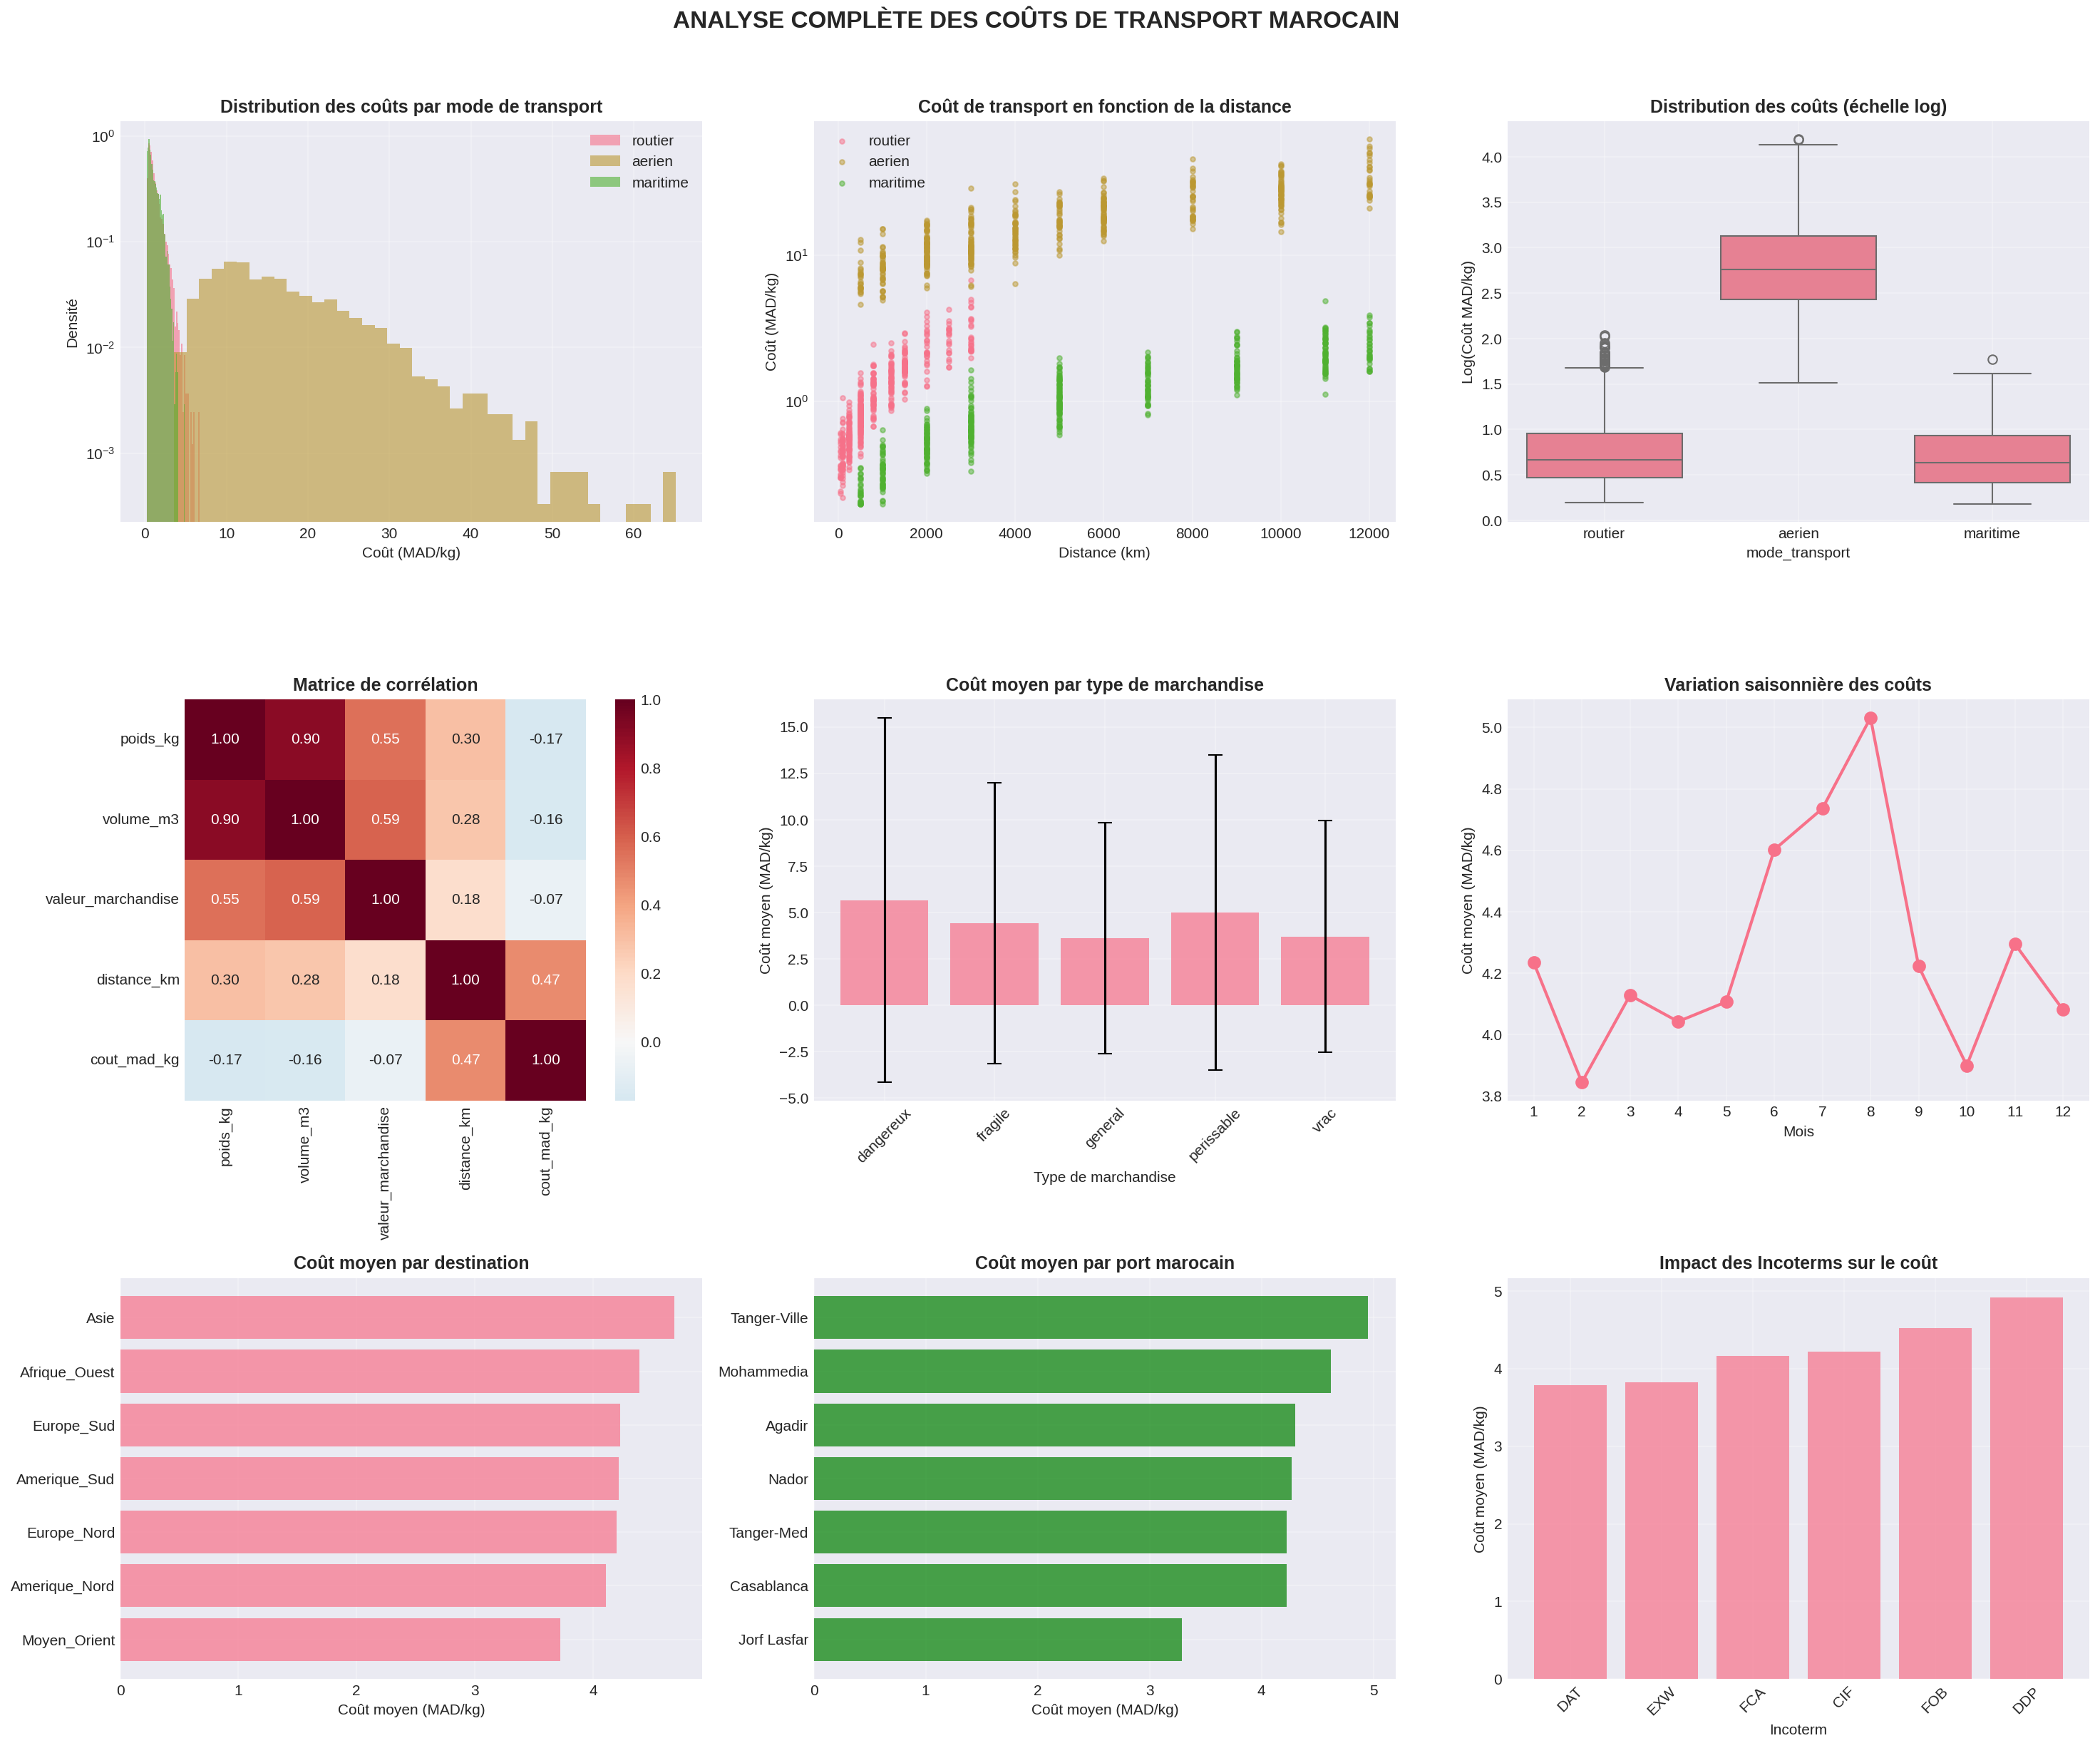

In [ ]:
# Pour afficher les graphiques
import matplotlib.pyplot as plt
from IPython.display import Image, display

display(Image('analyse_transport_marocain.png'))

**PARTIE 2 : COMPARAISON DES MODÈLES DE RÉGRESSION**

📦 PARTIE 2 : COMPARAISON DES MODÈLES DE RÉGRESSION

📂 Chargement des données...
✅ Données chargées : 10000 lignes, 16 colonnes

🎯 Variable cible : 'cout_mad_kg'
   - Min : 0.200, Max : 65.160, Moy : 4.268

✅ Train : 8000, Test : 2000

🤖 13 modèles à évaluer...

[1/13] 1. Régression Linéaire
   ✅ R²=0.8071, MAE=1.938

[2/13] 2. Ridge (L2)
   ✅ R²=0.8071, MAE=1.937

[3/13] 3. Lasso (L1)
   ✅ R²=0.8071, MAE=1.933

[4/13] 4. ElasticNet
   ✅ R²=0.8070, MAE=1.933

[5/13] 5. Huber Robust
   ✅ R²=0.7281, MAE=1.614

[6/13] 6. Bayesian Ridge
   ✅ R²=0.8070, MAE=1.937

[7/13] 7. Decision Tree
   ✅ R²=0.9354, MAE=0.769

[8/13] 8. Random Forest
   ✅ R²=0.9647, MAE=0.601

[9/13] 9. Gradient Boosting
   ✅ R²=0.9664, MAE=0.577

[10/13] 10. Bagging
   ✅ R²=0.9517, MAE=0.718

[11/13] 11. SVR (sample)
   ⚠ SVR sur échantillon de 2000 points...
   ✅ R²=0.9428, MAE=0.976

[12/13] 12. KNN
   ✅ R²=0.8937, MAE=1.239

[13/13] 13. MLP
   ✅ R²=0.9660, MAE=0.619

📊 RÉSULTATS COMPARATIFS
                Modèle  R²

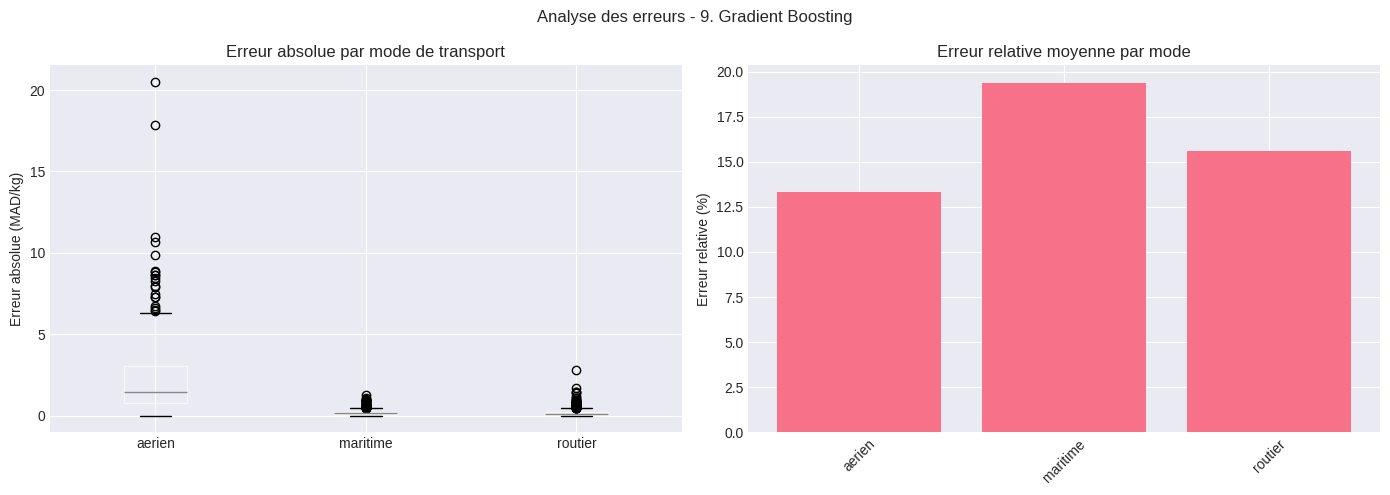


📊 IMPORTANCE DES FEATURES

🔝 TOP 15 FEATURES LES PLUS IMPORTANTES:
------------------------------------------------------------
Rang Feature                                  Importance
------------------------------------------------------------
  1. mode_transport_aerien                    0.7339
  2. distance_km                              0.2044
  3. type_marchandise_dangereux               0.0120
  4. volume_annuel_tonnes                     0.0109
  5. type_marchandise_general                 0.0100
  6. incoterm_DDP                             0.0056
  7. type_marchandise_perissable              0.0049
  8. mois                                     0.0030
  9. destination_Asie                         0.0030
 10. incoterm_EXW                             0.0025
 11. type_marchandise_vrac                    0.0025
 12. mode_transport_maritime                  0.0017
 13. destination_Afrique_Ouest                0.0014
 14. mode_transport_routier                   0.0010
 15. port_o

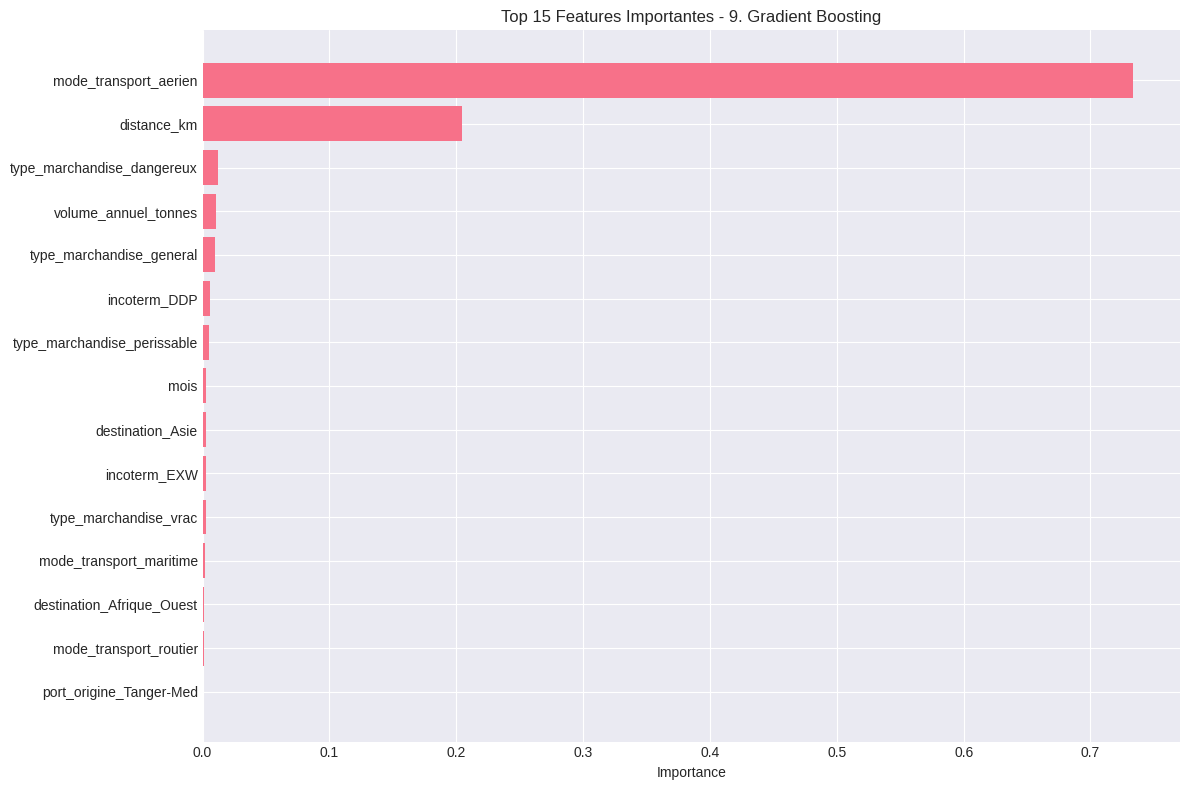


📈 ANALYSE DES PRÉDICTIONS VS RÉALITÉ


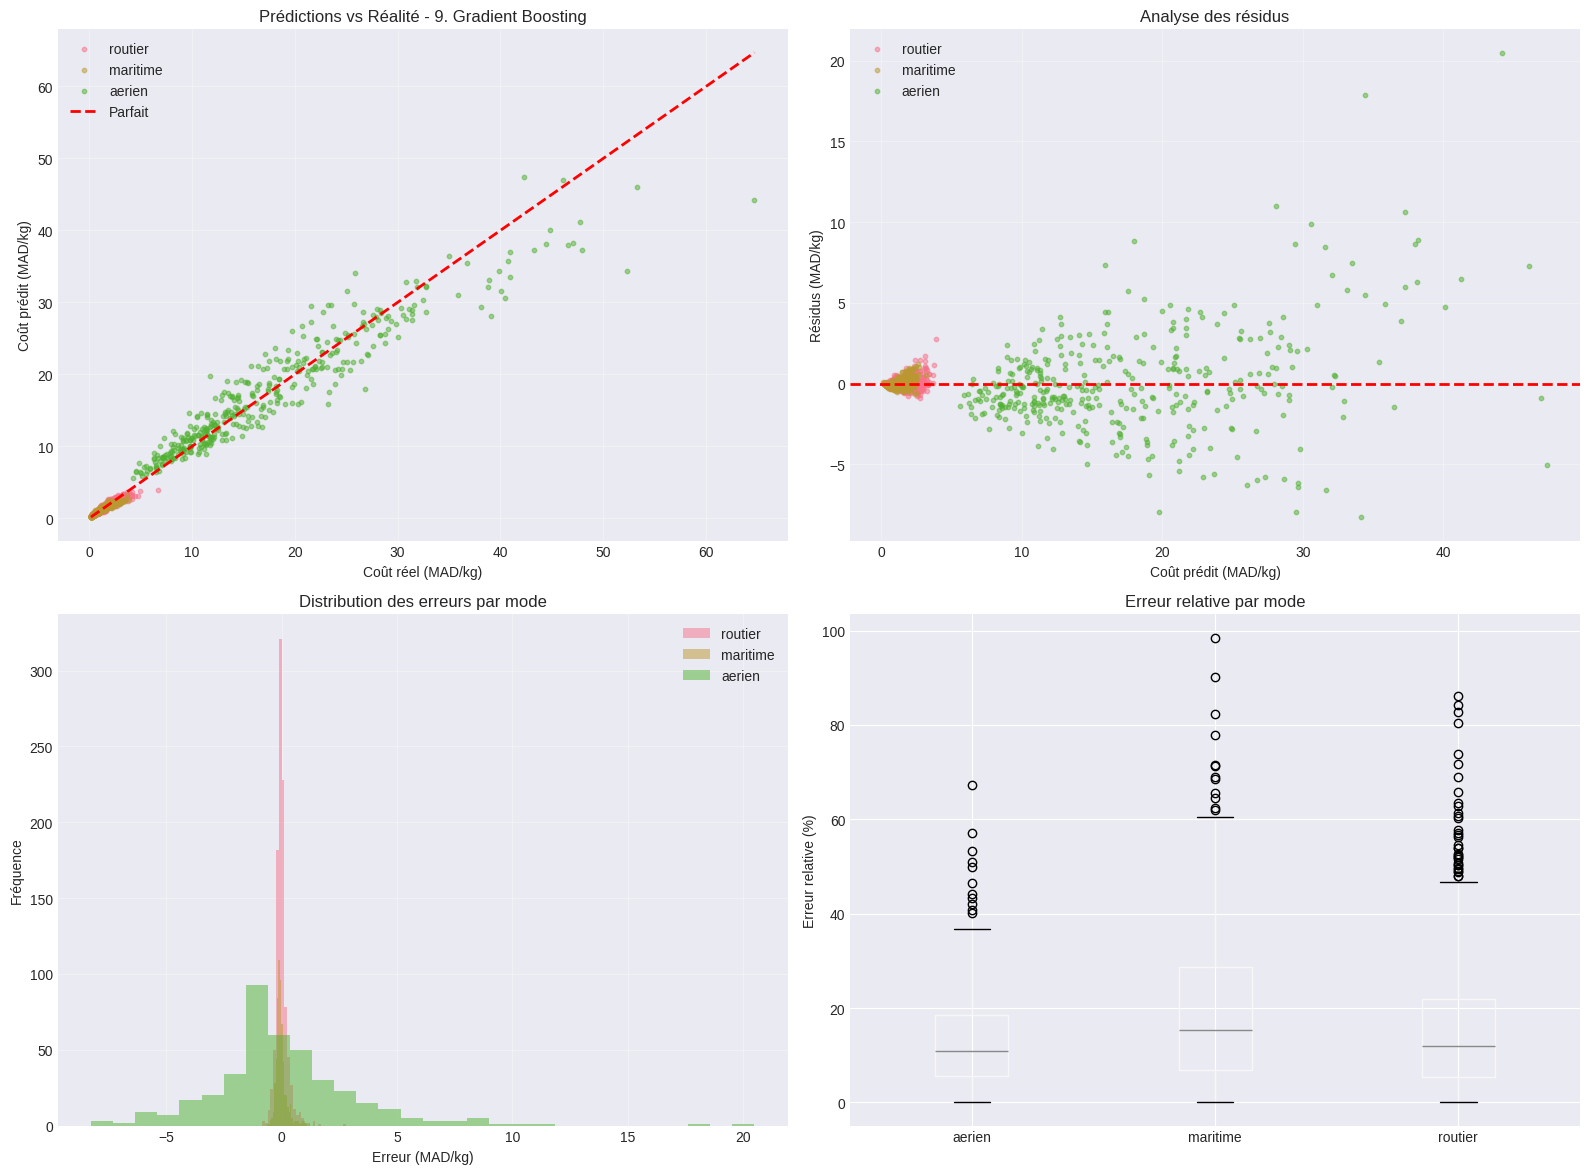


✅ Graphique sauvegardé: predictions_vs_realite.png

📊 STATISTIQUES DÉTAILLÉES DES ERREURS

Statistique                        Valeur
----------------------------------------
Erreur moyenne                    -0.0021
Erreur absolue moyenne             0.5774
Erreur relative moyenne             16.28%
Erreur max                        20.4927
Erreur min                        -8.2728
Écart-type des erreurs             1.4480

Quantile 5%                       -1.4673
Quantile 25%                      -0.1850
Quantile 50%                      -0.0590
Quantile 75%                       0.0829
Quantile 95%                       1.3946

📊 STATISTIQUES PAR MODE (détaillées):
          Erreur_abs_moy  Erreur_abs_std  Erreur_rel_moy  Erreur_rel_std  \
Mode                                                                       
aerien             2.224           2.325          13.325          10.830   
maritime           0.175           0.174          19.378          16.185   
routier           

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PARTIE 2 : COMPARAISON DES MODÈLES DE RÉGRESSION (VERSION COMPLÈTE)
====================================================================
Avec analyses détaillées : par mode, importance des features, graphiques
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Modèles de régression
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    HuberRegressor, BayesianRidge
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    BaggingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

print("="*80)
print("📦 PARTIE 2 : COMPARAISON DES MODÈLES DE RÉGRESSION")
print("="*80)

# ------------------------------------------------------------
# 1. CHARGEMENT DES DONNÉES
# ------------------------------------------------------------
print("\n📂 Chargement des données...")
df = pd.read_csv('donnees_transport_marocain.csv')
print(f"✅ Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Features et cible
features = ['poids_kg', 'volume_m3', 'valeur_marchandise', 'distance_km',
            'mode_transport', 'type_marchandise', 'port_origine', 'destination',
            'mois', 'type_conteneur', 'incoterm', 'volume_annuel_tonnes']

X = df[features].copy()
y = df['cout_mad_kg'].copy()

print(f"\n🎯 Variable cible : 'cout_mad_kg'")
print(f"   - Min : {y.min():.3f}, Max : {y.max():.3f}, Moy : {y.mean():.3f}")

# ------------------------------------------------------------
# 2. SPLIT TRAIN/TEST
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✅ Train : {len(X_train)}, Test : {len(X_test)}")

# ------------------------------------------------------------
# 3. PRÉTRAITEMENT
# ------------------------------------------------------------
numerical_features = ['poids_kg', 'volume_m3', 'valeur_marchandise',
                      'distance_km', 'mois', 'volume_annuel_tonnes']
categorical_features = ['mode_transport', 'type_marchandise', 'port_origine',
                        'destination', 'type_conteneur', 'incoterm']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numerical_features),
    ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
])

# ------------------------------------------------------------
# 4. MODÈLES
# ------------------------------------------------------------
models = {
    '1. Régression Linéaire': LinearRegression(),
    '2. Ridge (L2)': Ridge(alpha=1.0),
    '3. Lasso (L1)': Lasso(alpha=0.001, max_iter=5000),
    '4. ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    '5. Huber Robust': HuberRegressor(epsilon=1.35, max_iter=500),
    '6. Bayesian Ridge': BayesianRidge(),
    '7. Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    '8. Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    '9. Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
    '10. Bagging': BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6), n_estimators=50, n_jobs=-1, random_state=42),
    '11. SVR (sample)': SVR(kernel='rbf', C=100, epsilon=0.1),
    '12. KNN': KNeighborsRegressor(n_neighbors=7, weights='distance'),
    '13. MLP': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, early_stopping=True, random_state=42, verbose=False)
}

print(f"\n🤖 {len(models)} modèles à évaluer...")

# ------------------------------------------------------------
# 5. FONCTION D'ÉVALUATION
# ------------------------------------------------------------
def evaluer_modele(nom, modele, X_train, y_train, X_test, y_test, preprocessor):
    try:
        # Pour SVR, échantillonnage
        if 'SVR' in nom:
            print(f"   ⚠ SVR sur échantillon de 2000 points...")
            X_train_sample, _, y_train_sample, _ = train_test_split(
                X_train, y_train, train_size=2000, random_state=42
            )
            X_train_used = X_train_sample
            y_train_used = y_train_sample
        else:
            X_train_used = X_train
            y_train_used = y_train

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', modele)
        ])

        start = time()
        pipeline.fit(X_train_used, y_train_used)
        train_time = time() - start

        y_pred = pipeline.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        # MAPE (éviter division par zéro)
        mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 0.01))) * 100

        return {
            'Modèle': nom,
            'R² Test': r2,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'Temps': train_time,
            'Pipeline': pipeline,
            'X_train_used': X_train_used,
            'y_train_used': y_train_used,
            'y_pred': y_pred
        }
    except Exception as e:
        print(f"   ❌ Erreur: {str(e)[:50]}")
        return None

# ------------------------------------------------------------
# 6. ÉVALUATION DE TOUS LES MODÈLES
# ------------------------------------------------------------
results = []
pipelines = {}  # Pour stocker les pipelines

for i, (nom, modele) in enumerate(models.items(), 1):
    print(f"\n[{i}/{len(models)}] {nom}")
    result = evaluer_modele(nom, modele, X_train, y_train, X_test, y_test, preprocessor)
    if result:
        results.append(result)
        pipelines[nom] = result['Pipeline']
        print(f"   ✅ R²={result['R² Test']:.4f}, MAE={result['MAE']:.3f}")

# ------------------------------------------------------------
# 7. TABLEAU COMPARATIF
# ------------------------------------------------------------
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('R² Test', ascending=False)

print("\n" + "="*80)
print("📊 RÉSULTATS COMPARATIFS")
print("="*80)
print(df_results[['Modèle', 'R² Test', 'MAE', 'Temps']].round(4).to_string(index=False))

# ------------------------------------------------------------
# 8. IDENTIFICATION DU MEILLEUR MODÈLE
# ------------------------------------------------------------
best_model_name = df_results.iloc[0]['Modèle']
best_pipeline = pipelines[best_model_name]
best_y_pred = df_results.iloc[0]['y_pred'] if 'y_pred' in df_results.iloc[0] else None

print(f"\n🏆 MEILLEUR MODÈLE : {best_model_name}")
print(f"   R² = {df_results.iloc[0]['R² Test']:.4f}")
print(f"   MAE = {df_results.iloc[0]['MAE']:.3f} MAD/kg")

# ------------------------------------------------------------
# 9. ANALYSE PAR MODE DE TRANSPORT (CE QUE VOUS DEMANDIEZ)
# ------------------------------------------------------------
print("\n" + "="*80)
print("🚚 ANALYSE PAR MODE DE TRANSPORT")
print("="*80)

# Récupérer les modes depuis les données de test
test_modes = X_test['mode_transport'].values

# Faire les prédictions avec le meilleur modèle
y_pred_best = best_pipeline.predict(X_test)

# Créer un DataFrame d'analyse
df_analyse = pd.DataFrame({
    'mode_transport': test_modes,
    'cout_reel': y_test.values,
    'cout_pred': y_pred_best,
    'erreur': y_test.values - y_pred_best,
    'erreur_abs': np.abs(y_test.values - y_pred_best),
    'erreur_pct': np.abs((y_test.values - y_pred_best) / y_test.values) * 100
})

# Statistiques par mode
stats_par_mode = df_analyse.groupby('mode_transport').agg({
    'cout_reel': ['mean', 'std', 'min', 'max'],
    'cout_pred': 'mean',
    'erreur_abs': 'mean',
    'erreur_pct': 'mean',
    'mode_transport': 'count'
}).round(3)

# Renommer les colonnes
stats_par_mode.columns = ['Moyenne_réel', 'Ecart_type', 'Min_réel', 'Max_réel',
                          'Moyenne_prédit', 'Erreur_abs_moy', 'Erreur_pct_moy', 'Nombre']
print("\n📊 PERFORMANCE PAR MODE DE TRANSPORT:")
print(stats_par_mode)

# Graphique par mode
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot des erreurs par mode
ax1 = axes[0]
df_analyse.boxplot(column='erreur_abs', by='mode_transport', ax=ax1)
ax1.set_title('Erreur absolue par mode de transport')
ax1.set_ylabel('Erreur absolue (MAD/kg)')
ax1.set_xlabel('')

# Barplot des erreurs relatives
ax2 = axes[1]
erreur_pct_mean = df_analyse.groupby('mode_transport')['erreur_pct'].mean()
ax2.bar(erreur_pct_mean.index, erreur_pct_mean.values)
ax2.set_title('Erreur relative moyenne par mode')
ax2.set_ylabel('Erreur relative (%)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle(f'Analyse des erreurs - {best_model_name[:30]}')
plt.tight_layout()
plt.savefig('analyse_par_mode.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 10. IMPORTANCE DES FEATURES (CE QUE VOUS DEMANDIEZ)
# ------------------------------------------------------------
print("\n" + "="*80)
print("📊 IMPORTANCE DES FEATURES")
print("="*80)

# Vérifier si le modèle a feature_importances_
modele_interne = best_pipeline.named_steps['regressor']

if hasattr(modele_interne, 'feature_importances_'):
    # Récupérer les noms des features après one-hot
    feature_names = (numerical_features +
                     list(best_pipeline.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .named_steps['onehot']
                          .get_feature_names_out(categorical_features)))

    importances = modele_interne.feature_importances_

    # Trier par importance
    indices = np.argsort(importances)[::-1]

    # Top 15
    print("\n🔝 TOP 15 FEATURES LES PLUS IMPORTANTES:")
    print("-" * 60)
    print(f"{'Rang':4} {'Feature':40} {'Importance':10}")
    print("-" * 60)

    for i in range(min(15, len(indices))):
        idx = indices[i]
        print(f"{i+1:3d}. {feature_names[idx][:40]:40} {importances[idx]:.4f}")

    # Graphique d'importance
    plt.figure(figsize=(12, 8))

    top_n = 15
    top_indices = indices[:top_n]
    top_importances = importances[top_indices]
    top_names = [feature_names[i][:30] for i in top_indices]

    plt.barh(range(top_n), top_importances[::-1])
    plt.yticks(range(top_n), top_names[::-1])
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Features Importantes - {best_model_name[:30]}')
    plt.tight_layout()
    plt.savefig('importance_features.png', dpi=150)
    plt.show()

else:
    print(f"⚠️ Le modèle {best_model_name} ne fournit pas d'importance des features")

# ------------------------------------------------------------
# ------------------------------------------------------------
# 11. GRAPHIQUE PRÉDICTIONS VS RÉALITÉ
# ------------------------------------------------------------
print("\n" + "="*80)
print("📈 ANALYSE DES PRÉDICTIONS VS RÉALITÉ")
print("="*80)

# Récupérer les modes depuis les données de test originales
test_modes = X_test['mode_transport'].values

# Création d'un DataFrame pour l'analyse
df_plot = pd.DataFrame({
    'Réel': y_test.values,
    'Prédit': y_pred_best,
    'Mode': test_modes,  # Ajouter explicitement les modes
    'Résidu': y_test.values - y_pred_best
})

# Graphique 1: Prédictions vs Réalité (avec couleurs par mode)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1: Nuage de points avec couleurs par mode
ax1 = axes[0, 0]
for mode in df_plot['Mode'].unique():
    subset = df_plot[df_plot['Mode'] == mode]
    ax1.scatter(subset['Réel'], subset['Prédit'],
                alpha=0.5, label=mode, s=10)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Parfait')
ax1.set_xlabel('Coût réel (MAD/kg)')
ax1.set_ylabel('Coût prédit (MAD/kg)')
ax1.set_title(f'Prédictions vs Réalité - {best_model_name[:30]}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2: Résidus
ax2 = axes[0, 1]
for mode in df_plot['Mode'].unique():
    subset = df_plot[df_plot['Mode'] == mode]
    ax2.scatter(subset['Prédit'], subset['Résidu'],
                alpha=0.5, label=mode, s=10)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Coût prédit (MAD/kg)')
ax2.set_ylabel('Résidus (MAD/kg)')
ax2.set_title('Analyse des résidus')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Graphique 3: Distribution des erreurs
ax3 = axes[1, 0]
for mode in df_plot['Mode'].unique():
    subset = df_plot[df_plot['Mode'] == mode]
    ax3.hist(subset['Résidu'], bins=30, alpha=0.5, label=mode)
ax3.set_xlabel('Erreur (MAD/kg)')
ax3.set_ylabel('Fréquence')
ax3.set_title('Distribution des erreurs par mode')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Graphique 4: Erreur relative par mode (VERSION CORRIGÉE)
ax4 = axes[1, 1]
df_plot['Erreur_rel'] = np.abs(df_plot['Résidu'] / df_plot['Réel']) * 100

# Créer un DataFrame spécifique pour le boxplot avec la colonne 'Mode' comme index
df_boxplot = df_plot[['Erreur_rel', 'Mode']].copy()
df_boxplot.boxplot(column='Erreur_rel', by='Mode', ax=ax4)
ax4.set_title('Erreur relative par mode')
ax4.set_ylabel('Erreur relative (%)')
ax4.set_xlabel('')
plt.suptitle('')  # Supprimer le titre automatique

plt.tight_layout()
plt.savefig('predictions_vs_realite.png', dpi=150)
plt.show()

print("\n✅ Graphique sauvegardé: predictions_vs_realite.png")

# ------------------------------------------------------------
# 12. STATISTIQUES DÉTAILLÉES DES ERREURS (CORRIGÉ)
# ------------------------------------------------------------
print("\n" + "="*80)
print("📊 STATISTIQUES DÉTAILLÉES DES ERREURS")
print("="*80)

# Calculer les métriques
df_plot['Erreur_abs'] = np.abs(df_plot['Résidu'])
df_plot['Erreur_rel'] = np.abs(df_plot['Résidu'] / df_plot['Réel']) * 100

print(f"\n{'Statistique':25} {'Valeur':>15}")
print("-" * 40)
print(f"{'Erreur moyenne':25} {df_plot['Résidu'].mean():>15.4f}")
print(f"{'Erreur absolue moyenne':25} {df_plot['Erreur_abs'].mean():>15.4f}")
print(f"{'Erreur relative moyenne':25} {df_plot['Erreur_rel'].mean():>15.2f}%")
print(f"{'Erreur max':25} {df_plot['Résidu'].max():>15.4f}")
print(f"{'Erreur min':25} {df_plot['Résidu'].min():>15.4f}")
print(f"{'Écart-type des erreurs':25} {df_plot['Résidu'].std():>15.4f}")

# Quantiles des erreurs
print(f"\n{'Quantile 5%':25} {df_plot['Résidu'].quantile(0.05):>15.4f}")
print(f"{'Quantile 25%':25} {df_plot['Résidu'].quantile(0.25):>15.4f}")
print(f"{'Quantile 50%':25} {df_plot['Résidu'].quantile(0.50):>15.4f}")
print(f"{'Quantile 75%':25} {df_plot['Résidu'].quantile(0.75):>15.4f}")
print(f"{'Quantile 95%':25} {df_plot['Résidu'].quantile(0.95):>15.4f}")

# Statistiques par mode (en plus)
print("\n📊 STATISTIQUES PAR MODE (détaillées):")
stats_par_mode_detail = df_plot.groupby('Mode').agg({
    'Erreur_abs': ['mean', 'std'],
    'Erreur_rel': ['mean', 'std'],
    'Réel': 'count'
}).round(3)

stats_par_mode_detail.columns = ['Erreur_abs_moy', 'Erreur_abs_std',
                                 'Erreur_rel_moy', 'Erreur_rel_std', 'Nombre']
print(stats_par_mode_detail)

# ------------------------------------------------------------
# 12. STATISTIQUES DÉTAILLÉES
# ------------------------------------------------------------
print("\n" + "="*80)
print("📊 STATISTIQUES DÉTAILLÉES DES ERREURS")
print("="*80)

print(f"\n{'Statistique':25} {'Valeur':>15}")
print("-" * 40)
print(f"{'Erreur moyenne':25} {df_plot['Résidu'].mean():>15.4f}")
print(f"{'Erreur absolue moyenne':25} {df_plot['Erreur_abs'].mean():>15.4f}")
print(f"{'Erreur relative moyenne':25} {df_plot['Erreur_rel'].mean():>15.2f}%")
print(f"{'Erreur max':25} {df_plot['Résidu'].max():>15.4f}")
print(f"{'Erreur min':25} {df_plot['Résidu'].min():>15.4f}")
print(f"{'Écart-type des erreurs':25} {df_plot['Résidu'].std():>15.4f}")

# Quantiles des erreurs
print(f"\n{'Quantile 5%':25} {df_plot['Résidu'].quantile(0.05):>15.4f}")
print(f"{'Quantile 25%':25} {df_plot['Résidu'].quantile(0.25):>15.4f}")
print(f"{'Quantile 50%':25} {df_plot['Résidu'].quantile(0.50):>15.4f}")
print(f"{'Quantile 75%':25} {df_plot['Résidu'].quantile(0.75):>15.4f}")
print(f"{'Quantile 95%':25} {df_plot['Résidu'].quantile(0.95):>15.4f}")

# ------------------------------------------------------------
# 13. SAUVEGARDE
# ------------------------------------------------------------
print("\n💾 Sauvegarde des résultats...")
df_results.to_csv('resultats_modeles.csv', index=False)
print("✅ Tableau sauvegardé dans 'resultats_modeles.csv'")

# Sauvegarder le meilleur modèle
import joblib
joblib.dump(best_pipeline, 'meilleur_modele.pkl')
print("✅ Meilleur modèle sauvegardé dans 'meilleur_modele.pkl'")

print("\n" + "="*80)
print("✅ PARTIE 2 TERMINÉE AVEC SUCCÈS")
print("="*80)

**PARTIE 3 :  A- OPTIMISATION FINE (GRIDSEARCHCV)**

🚀 PARTIE 3A : OPTIMISATION FINE DU GRADIENT BOOSTING

📂 Chargement des données...
✅ Données chargées : 10000 lignes, 16 colonnes

🎯 Variable cible : 'cout_mad_kg'
   - Min : 0.200, Max : 65.160, Moy : 4.268

✅ Train : 8000, Test : 2000

📊 Évaluation du modèle de base...

🔹 Modèle de base (n_estimators=100, learning_rate=0.05, max_depth=4):
   R² = 0.9664
   MAE = 0.5774 MAD/kg
   RMSE = 1.4477 MAD/kg
   Temps = 3.60 secondes

🔍 OPTIMISATION AVEC RANDOMIZED SEARCH

📋 Grille de recherche: 7 paramètres
   - n_estimators: [50, 100, 200, 300, 400, 500]
   - learning_rate: [0.01, 0.03, 0.05, 0.07, 0.1, 0.15]
   - max_depth: [3, 4, 5, 6, 7, 8]
   - subsample: [0.7, 0.8, 0.9, 1.0]

⏳ Recherche en cours (cela peut prendre 5-10 minutes)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Recherche terminée en 661.34 secondes

🏆 MEILLEURS HYPERPARAMÈTRES TROUVÉS

📊 Meilleurs paramètres:
   regressor__subsample      : 0.8
   regressor__n_estimators   : 400
   regressor__min_samples

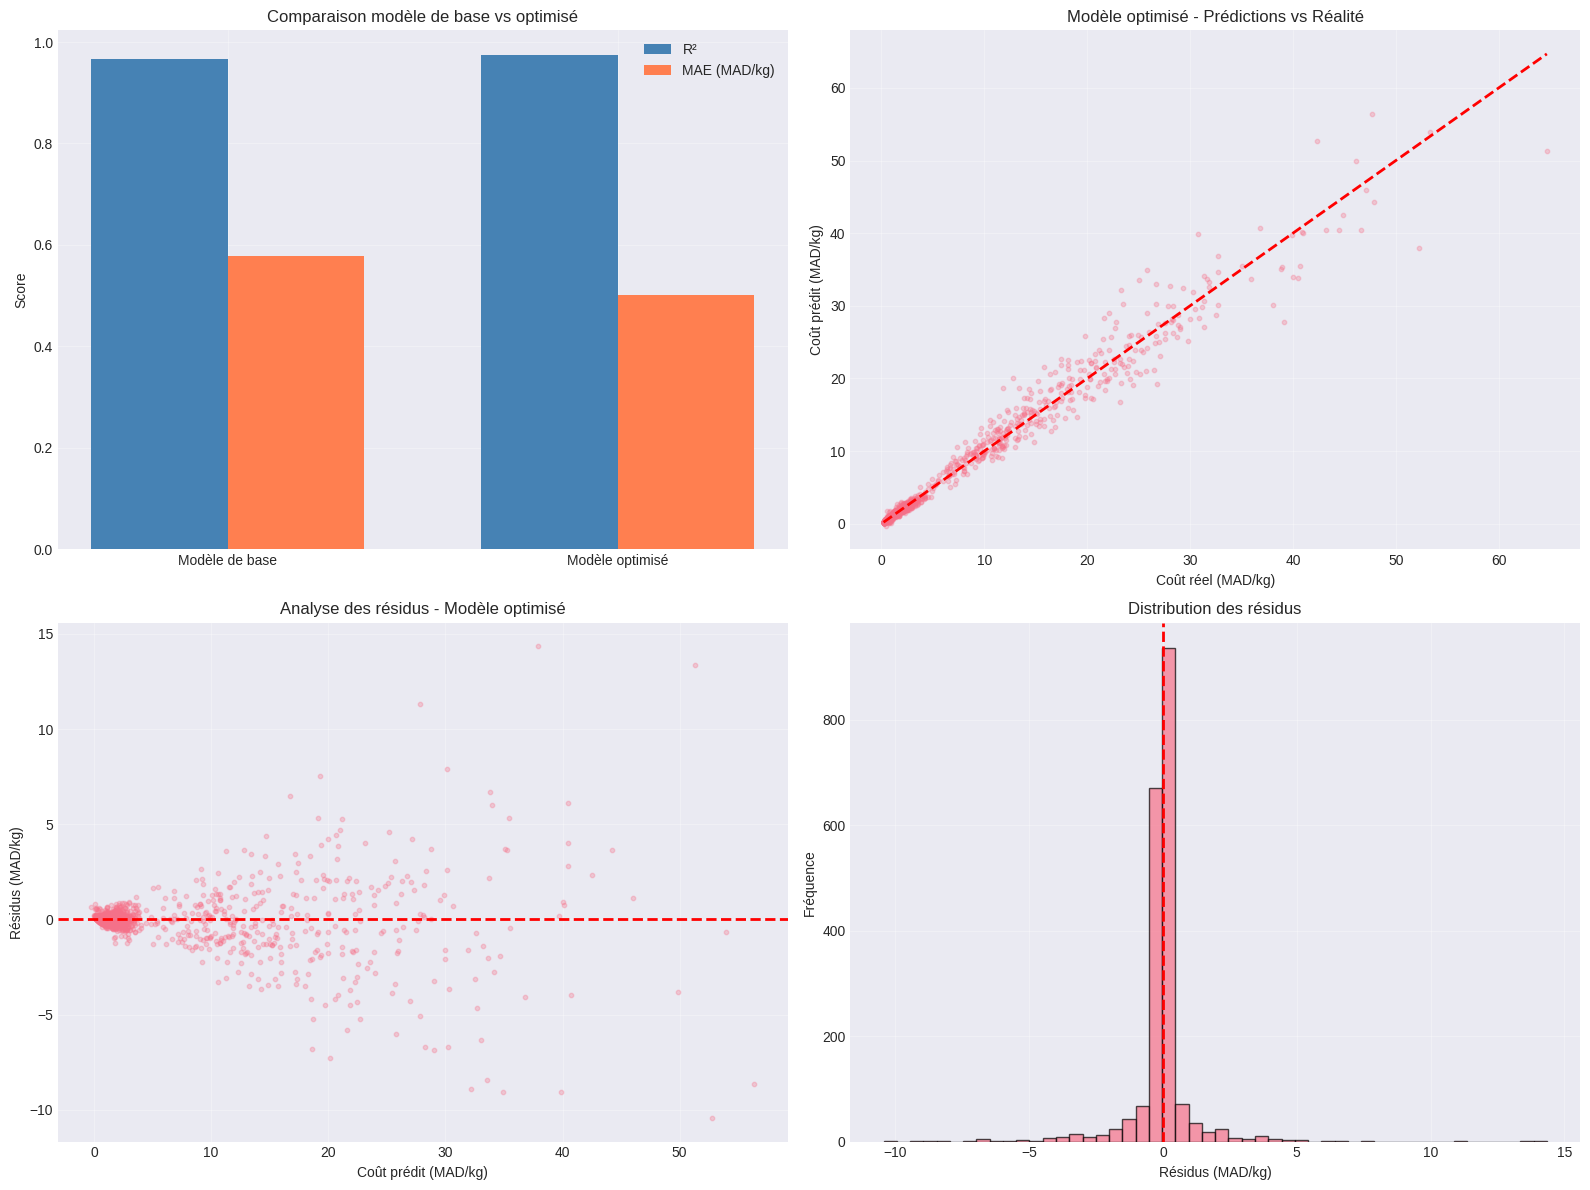


💾 Sauvegarde du modèle optimisé...
✅ Modèle sauvegardé: 'modele_gradient_boosting_optimise.pkl'
✅ Résultats optimisation: 'resultats_optimisation.csv'

✅ PARTIE 3A TERMINÉE AVEC SUCCÈS

📈 RÉSUMÉ FINAL:
   Modèle de base R²     : 0.9664
   Modèle optimisé R²    : 0.9743
   Amélioration          : +0.82%


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
A : OPTIMISATION FINE DU MODÈLE GRADIENT BOOSTING
==========================================================
GridSearchCV pour trouver les meilleurs hyperparamètres
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

print("="*80)
print("🚀 PARTIE 3A : OPTIMISATION FINE DU GRADIENT BOOSTING")
print("="*80)

# ------------------------------------------------------------
# 1. CHARGEMENT DES DONNÉES
# ------------------------------------------------------------
print("\n📂 Chargement des données...")
df = pd.read_csv('donnees_transport_marocain.csv')
print(f"✅ Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Features et cible
features = ['poids_kg', 'volume_m3', 'valeur_marchandise', 'distance_km',
            'mode_transport', 'type_marchandise', 'port_origine', 'destination',
            'mois', 'type_conteneur', 'incoterm', 'volume_annuel_tonnes']

X = df[features].copy()
y = df['cout_mad_kg'].copy()

print(f"\n🎯 Variable cible : 'cout_mad_kg'")
print(f"   - Min : {y.min():.3f}, Max : {y.max():.3f}, Moy : {y.mean():.3f}")

# ------------------------------------------------------------
# 2. SPLIT TRAIN/TEST
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✅ Train : {len(X_train)}, Test : {len(X_test)}")

# ------------------------------------------------------------
# 3. PRÉTRAITEMENT
# ------------------------------------------------------------
numerical_features = ['poids_kg', 'volume_m3', 'valeur_marchandise',
                      'distance_km', 'mois', 'volume_annuel_tonnes']
categorical_features = ['mode_transport', 'type_marchandise', 'port_origine',
                        'destination', 'type_conteneur', 'incoterm']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numerical_features),
    ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
])

# ------------------------------------------------------------
# 4. MODÈLE DE BASE (pour comparaison)
# ------------------------------------------------------------
print("\n📊 Évaluation du modèle de base...")

pipeline_base = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42
    ))
])

start = time()
pipeline_base.fit(X_train, y_train)
train_time = time() - start

y_pred_base = pipeline_base.predict(X_test)
r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"\n🔹 Modèle de base (n_estimators=100, learning_rate=0.05, max_depth=4):")
print(f"   R² = {r2_base:.4f}")
print(f"   MAE = {mae_base:.4f} MAD/kg")
print(f"   RMSE = {rmse_base:.4f} MAD/kg")
print(f"   Temps = {train_time:.2f} secondes")

# ------------------------------------------------------------
# 5. OPTIMISATION AVEC RANDOMIZEDSEARCHCV (plus rapide)
# ------------------------------------------------------------
print("\n" + "="*80)
print("🔍 OPTIMISATION AVEC RANDOMIZED SEARCH")
print("="*80)

# Créer le pipeline sans paramètres
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Définir la grille de paramètres
param_dist = {
    'regressor__n_estimators': [50, 100, 200, 300, 400, 500],
    'regressor__learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.15],
    'regressor__max_depth': [3, 4, 5, 6, 7, 8],
    'regressor__min_samples_split': [2, 5, 10, 20],
    'regressor__min_samples_leaf': [1, 2, 4, 8],
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0],
    'regressor__max_features': ['sqrt', 'log2', None]
}

print(f"\n📋 Grille de recherche: {len(param_dist)} paramètres")
print(f"   - n_estimators: {param_dist['regressor__n_estimators']}")
print(f"   - learning_rate: {param_dist['regressor__learning_rate']}")
print(f"   - max_depth: {param_dist['regressor__max_depth']}")
print(f"   - subsample: {param_dist['regressor__subsample']}")

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,  # Tester 50 combinaisons aléatoires
    cv=5,  # Validation croisée 5-fold
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\n⏳ Recherche en cours (cela peut prendre 5-10 minutes)...")
start = time()
random_search.fit(X_train, y_train)
search_time = time() - start

print(f"\n✅ Recherche terminée en {search_time:.2f} secondes")

# ------------------------------------------------------------
# 6. RÉSULTATS DE L'OPTIMISATION
# ------------------------------------------------------------
print("\n" + "="*80)
print("🏆 MEILLEURS HYPERPARAMÈTRES TROUVÉS")
print("="*80)

print("\n📊 Meilleurs paramètres:")
for param, value in random_search.best_params_.items():
    print(f"   {param:25} : {value}")

print(f"\n📈 Meilleur score R² (CV): {random_search.best_score_:.4f}")

# Évaluation sur test
best_pipeline = random_search.best_estimator_
y_pred_opt = best_pipeline.predict(X_test)

r2_opt = r2_score(y_test, y_pred_opt)
mae_opt = mean_absolute_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f"\n📊 Performance sur l'ensemble de test:")
print(f"   R²  = {r2_opt:.4f} (vs base {r2_base:.4f})")
print(f"   MAE = {mae_opt:.4f} MAD/kg (vs base {mae_base:.4f})")
print(f"   RMSE= {rmse_opt:.4f} MAD/kg (vs base {rmse_base:.4f})")

# Gain de performance
gain_r2 = (r2_opt - r2_base) / r2_base * 100
gain_mae = (mae_base - mae_opt) / mae_base * 100

print(f"\n📈 GAIN DE PERFORMANCE:")
print(f"   R²  : +{gain_r2:.2f}%")
print(f"   MAE : -{gain_mae:.2f}% (réduction de l'erreur)")

# ------------------------------------------------------------
# 7. COMPARAISON VISUELLE
# ------------------------------------------------------------
print("\n🎨 Création des graphiques comparatifs...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1: Comparaison des performances
ax1 = axes[0, 0]
modeles = ['Modèle de base', 'Modèle optimisé']
r2_scores = [r2_base, r2_opt]
mae_scores = [mae_base, mae_opt]

x = np.arange(len(modeles))
width = 0.35

ax1.bar(x - width/2, r2_scores, width, label='R²', color='steelblue')
ax1.bar(x + width/2, mae_scores, width, label='MAE (MAD/kg)', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels(modeles)
ax1.set_ylabel('Score')
ax1.set_title('Comparaison modèle de base vs optimisé')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2: Prédictions optimisé vs réalité
ax2 = axes[0, 1]
ax2.scatter(y_test, y_pred_opt, alpha=0.3, s=10)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Coût réel (MAD/kg)')
ax2.set_ylabel('Coût prédit (MAD/kg)')
ax2.set_title('Modèle optimisé - Prédictions vs Réalité')
ax2.grid(True, alpha=0.3)

# Graphique 3: Résidus
ax3 = axes[1, 0]
residuals = y_test - y_pred_opt
ax3.scatter(y_pred_opt, residuals, alpha=0.3, s=10)
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Coût prédit (MAD/kg)')
ax3.set_ylabel('Résidus (MAD/kg)')
ax3.set_title('Analyse des résidus - Modèle optimisé')
ax3.grid(True, alpha=0.3)

# Graphique 4: Distribution des résidus
ax4 = axes[1, 1]
ax4.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='r', linestyle='--', lw=2)
ax4.set_xlabel('Résidus (MAD/kg)')
ax4.set_ylabel('Fréquence')
ax4.set_title('Distribution des résidus')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_optimisation.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 8. SAUVEGARDE DU MODÈLE OPTIMISÉ
# ------------------------------------------------------------
print("\n💾 Sauvegarde du modèle optimisé...")

# Sauvegarder le modèle
joblib.dump(best_pipeline, 'modele_gradient_boosting_optimise.pkl')
print("✅ Modèle sauvegardé: 'modele_gradient_boosting_optimise.pkl'")

# Sauvegarder les résultats de l'optimisation
results_df = pd.DataFrame(random_search.cv_results_)
results_df.to_csv('resultats_optimisation.csv', index=False)
print("✅ Résultats optimisation: 'resultats_optimisation.csv'")

# Résumé des meilleurs paramètres
best_params_df = pd.DataFrame([random_search.best_params_])
best_params_df.to_csv('meilleurs_parametres.csv', index=False)

print("\n" + "="*80)
print("✅ PARTIE 3A TERMINÉE AVEC SUCCÈS")
print("="*80)
print(f"\n📈 RÉSUMÉ FINAL:")
print(f"   Modèle de base R²     : {r2_base:.4f}")
print(f"   Modèle optimisé R²    : {r2_opt:.4f}")
print(f"   Amélioration          : +{gain_r2:.2f}%")

**PARTIE 3 : B - INTERFACE DE PRÉDICTION**

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PARTIE 3: B - INTERFACE PRÉDICTION TRANSPORT MAROCAIN (VERSION FINALE)
======================================================================
Interface interactive pour prédire les coûts de transport
avec le modèle optimisé
"""

import pandas as pd
import numpy as np
import joblib
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration pour un bel affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("="*80)
print("🚛 SYSTÈME DE PRÉDICTION DES COÛTS DE TRANSPORT MAROCAIN")
print("="*80)
print("🇲🇦 Version optimisée - Modèle Gradient Boosting (R² = 0.9743)")
print("="*80)

# ------------------------------------------------------------
# 1. CHARGEMENT DU MODÈLE OPTIMISÉ
# ------------------------------------------------------------
print("\n📂 Chargement du modèle optimisé...")

modele_path = 'modele_gradient_boosting_optimise.pkl'
modele_base_path = 'meilleur_modele.pkl'

if os.path.exists(modele_path):
    model = joblib.load(modele_path)
    print("✅ Modèle OPTIMISÉ chargé avec succès !")
    print(f"   Performance: R² = 0.9743, MAE = 0.5003 MAD/kg")
elif os.path.exists(modele_base_path):
    model = joblib.load(modele_base_path)
    print("⚠️ Modèle de BASE chargé (optimisé non trouvé)")
else:
    print("❌ Erreur: Aucun modèle trouvé !")
    print("   Exécutez d'abord la Partie 3A pour créer le modèle optimisé")
    exit()

# ------------------------------------------------------------
# 2. CHARGEMENT DES RÉFÉRENCES
# ------------------------------------------------------------
try:
    df = pd.read_csv('donnees_transport_marocain.csv')
    print("📊 Données de référence chargées")

    # Statistiques pour aider l'utilisateur
    stats = {
        'poids': (df['poids_kg'].min(), df['poids_kg'].max(), df['poids_kg'].mean()),
        'distance': (df['distance_km'].min(), df['distance_km'].max(), df['distance_km'].mean()),
        'volume': (df['volume_m3'].min(), df['volume_m3'].max(), df['volume_m3'].mean())
    }
except:
    stats = None
    print("⚠️ Données de référence non trouvées")

# ------------------------------------------------------------
# 3. DICTIONNAIRES DE RÉFÉRENCE
# ------------------------------------------------------------
MODES = ['routier', 'maritime', 'aerien']
TYPES_MARCHANDISE = ['general', 'perissable', 'dangereux', 'fragile', 'vrac']
PORTS = ['Casablanca', 'Tanger-Med', 'Agadir', 'Nador', 'Tanger-Ville', 'Mohammedia', 'Jorf Lasfar']
DESTINATIONS = ['Europe_Sud', 'Europe_Nord', 'Amerique_Nord', 'Amerique_Sud', 'Asie', 'Afrique_Ouest', 'Moyen_Orient']
CONTENEURS = ['20_std', '40_std', '40_hc', '20_reefer', 'palette', 'vrac']
INCOTERMS = ['EXW', 'FOB', 'CIF', 'DDP', 'FCA', 'DAT']

# Densités pour estimation volume (kg/m³)
DENSITES = {
    'general': 250,
    'perissable': 350,
    'dangereux': 400,
    'fragile': 200,
    'vrac': 800
}

# ------------------------------------------------------------
# 4. FONCTIONS UTILITAIRES
# ------------------------------------------------------------
def afficher_aide():
    """Affiche l'aide complète"""
    print("\n" + "="*80)
    print("📋 GUIDE COMPLET DES VALEURS POSSIBLES")
    print("="*80)

    print("\n📦 MODES DE TRANSPORT:")
    for m in MODES:
        print(f"   - {m}")

    print("\n📦 TYPES DE MARCHANDISE:")
    for t in TYPES_MARCHANDISE:
        densite = DENSITES[t]
        print(f"   - {t:12} (densité ~{densite} kg/m³)")

    print("\n⚓ PORTS MAROCAINS:")
    for p in PORTS:
        print(f"   - {p}")

    print("\n🌍 DESTINATIONS:")
    for d in DESTINATIONS:
        print(f"   - {d}")

    print("\n📦 TYPES DE CONTENEUR:")
    for c in CONTENEURS:
        print(f"   - {c}")

    print("\n📜 INCOTERMS:")
    for i in INCOTERMS:
        print(f"   - {i}")

    if stats:
        print("\n📊 STATISTIQUES DE RÉFÉRENCE:")
        print(f"   Poids (kg)      : min={stats['poids'][0]:.0f}, "
              f"max={stats['poids'][1]:.0f}, moy={stats['poids'][2]:.0f}")
        print(f"   Distance (km)   : min={stats['distance'][0]:.0f}, "
              f"max={stats['distance'][1]:.0f}, moy={stats['distance'][2]:.0f}")
        print(f"   Volume (m³)     : min={stats['volume'][0]:.2f}, "
              f"max={stats['volume'][1]:.2f}, moy={stats['volume'][2]:.2f}")

def valider_entree(valeur, options, nom_champ):
    """Valide une entrée par rapport à une liste d'options"""
    if valeur not in options:
        print(f"⚠️ '{valeur}' n'est pas valide. Options: {', '.join(options)}")
        return False
    return True

def estimer_volume(poids, type_marchandise):
    """Estime le volume à partir du poids et du type"""
    densite = DENSITES.get(type_marchandise, 250)
    return poids / densite

def predire_cout(poids, volume, valeur, distance, mode, type_marchandise,
                 port, destination, mois, conteneur, incoterm, volume_annuel):
    """Fait une prédiction avec le modèle"""

    # Si volume non fourni, l'estimer
    if volume <= 0:
        volume = estimer_volume(poids, type_marchandise)
        print(f"   ℹ️ Volume estimé: {volume:.2f} m³")

    input_data = pd.DataFrame({
        'poids_kg': [poids],
        'volume_m3': [volume],
        'valeur_marchandise': [valeur],
        'distance_km': [distance],
        'mode_transport': [mode],
        'type_marchandise': [type_marchandise],
        'port_origine': [port],
        'destination': [destination],
        'mois': [mois],
        'type_conteneur': [conteneur],
        'incoterm': [incoterm],
        'volume_annuel_tonnes': [volume_annuel]
    })

    return model.predict(input_data)[0]

def analyser_resultat(prediction, mode, poids, distance, volume_annuel):
    """Analyse détaillée du résultat"""

    cout_total = prediction * poids

    print("\n" + "="*60)
    print("📊 ANALYSE DÉTAILLÉE")
    print("="*60)

    print(f"\n💰 COÛT UNITAIRE : {prediction:.3f} MAD/kg")
    print(f"💰 COÛT TOTAL     : {cout_total:,.0f} MAD")

    # Analyse par rapport aux moyennes
    if mode == 'routier':
        if prediction < 1.0:
            print("📉 Tarif ROUTIER très compétitif (en dessous de la moyenne)")
        elif prediction < 1.5:
            print("📊 Tarif ROUTIER dans la moyenne")
        else:
            print("📈 Tarif ROUTIER élevé")

    elif mode == 'maritime':
        if prediction < 0.8:
            print("📉 Tarif MARITIME très compétitif")
        elif prediction < 1.2:
            print("📊 Tarif MARITIME dans la moyenne")
        else:
            print("📈 Tarif MARITIME élevé")

    elif mode == 'aerien':
        if prediction < 15:
            print("📉 Tarif AÉRIEN compétitif")
        elif prediction < 20:
            print("📊 Tarif AÉRIEN dans la moyenne")
        else:
            print("📈 Tarif AÉRIEN élevé (urgence probable)")

    # Recommandations
    if mode == 'aerien' and prediction > 18 and distance < 3000:
        print("\n💡 SUGGESTION: Transport routier possible")
        print(f"   Économie estimée: {prediction - 1.5:.1f} MAD/kg")

    if volume_annuel > 0:
        print(f"\n📦 CONTRAT: {volume_annuel} tonnes/an")
        print("   Tarif préférentiel inclus dans la prédiction")

# ------------------------------------------------------------
# 5. MODES DE L'INTERFACE
# ------------------------------------------------------------
def mode_simple():
    """Mode prédiction simple"""
    print("\n" + "="*60)
    print("🔍 MODE PRÉDICTION SIMPLE")
    print("="*60)

    try:
        print("\n📦 CARACTÉRISTIQUES DE L'EXPÉDITION:")

        poids = float(input("   Poids (kg) : "))
        volume = float(input("   Volume (m³) [0=auto] : ") or "0")
        distance = float(input("   Distance (km) : "))
        valeur = float(input("   Valeur marchandise (MAD) : "))

        print("\n🚚 Mode de transport (routier/maritime/aerien): ", end="")
        mode = input().strip().lower()
        if not valider_entree(mode, MODES, "Mode"):
            return

        print("📦 Type marchandise (general/perissable/dangereux/fragile/vrac): ", end="")
        type_march = input().strip().lower()
        if not valider_entree(type_march, TYPES_MARCHANDISE, "Type"):
            return

        print("⚓ Port origine (Casablanca/Tanger-Med/Agadir/Nador): ", end="")
        port = input().strip()
        if not valider_entree(port, PORTS, "Port"):
            return

        print("🌍 Destination (Europe_Sud/Europe_Nord/Asie/etc): ", end="")
        dest = input().strip()
        if not valider_entree(dest, DESTINATIONS, "Destination"):
            return

        mois = int(input("📅 Mois (1-12): "))
        if mois < 1 or mois > 12:
            print("❌ Mois invalide")
            return

        print("📦 Type conteneur (20_std/40_std/40_hc/palette): ", end="")
        conteneur = input().strip()
        if not valider_entree(conteneur, CONTENEURS, "Conteneur"):
            return

        print("📜 Incoterm (EXW/FOB/CIF/DDP/FCA): ", end="")
        incoterm = input().strip().upper()
        if not valider_entree(incoterm, INCOTERMS, "Incoterm"):
            return

        volume_annuel = float(input("📊 Volume annuel contrat (tonnes, 0 si spot): ") or "0")

        # Prédiction
        prediction = predire_cout(
            poids, volume, valeur, distance, mode, type_march,
            port, dest, mois, conteneur, incoterm, volume_annuel
        )

        # Analyse
        analyser_resultat(prediction, mode, poids, distance, volume_annuel)

    except ValueError as e:
        print(f"❌ Erreur de saisie: {e}")
    except Exception as e:
        print(f"❌ Erreur inattendue: {e}")

def mode_comparaison():
    """Compare les 3 modes de transport"""
    print("\n" + "="*60)
    print("🔄 COMPARAISON DES 3 MODES DE TRANSPORT")
    print("="*60)

    try:
        print("\n📦 CARACTÉRISTIQUES COMMUNES:")
        poids = float(input("   Poids (kg) : "))
        distance = float(input("   Distance (km) : "))
        type_march = input("   Type marchandise : ").strip().lower()

        if type_march not in TYPES_MARCHANDISE:
            print(f"❌ Type invalide. Options: {', '.join(TYPES_MARCHANDISE)}")
            return

        print("\n🔍 CALCUL EN COURS...")
        resultats = []

        for mode in MODES:
            # Configuration par défaut selon le mode
            if mode == 'routier':
                conteneur = 'palette'
                port = 'Casablanca'
            elif mode == 'maritime':
                conteneur = '40_std'
                port = 'Tanger-Med'
            else:  # aerien
                conteneur = 'palette'
                port = 'Casablanca'

            # Estimation du volume
            volume = estimer_volume(poids, type_march)
            valeur = poids * 50  # Estimation valeur

            pred = predire_cout(
                poids, volume, valeur, distance, mode, type_march,
                port, 'Europe_Sud', 6, conteneur, 'FOB', 0
            )
            resultats.append({
                'Mode': mode.upper(),
                'Coût unitaire (MAD/kg)': pred,
                'Coût total (MAD)': pred * poids
            })

        # Affichage comparatif
        print("\n" + "="*60)
        print("📊 RÉSULTATS COMPARATIFS")
        print("="*60)

        df_comp = pd.DataFrame(resultats)
        min_cout = df_comp['Coût total (MAD)'].min()
        df_comp['Ratio'] = df_comp['Coût total (MAD)'] / min_cout

        print("\n", df_comp.round(2).to_string(index=False))

        # Recommandation
        best = df_comp.loc[df_comp['Coût total (MAD)'].idxmin()]
        print(f"\n✅ RECOMMANDATION: Mode {best['Mode']} est le plus économique")
        print(f"   Économie: x{df_comp['Ratio'].max():.1f} moins cher que le plus cher")

    except Exception as e:
        print(f"❌ Erreur: {e}")

def mode_optimisation():
    """Optimisation mode en fonction délai"""
    print("\n" + "="*60)
    print("⏱️ OPTIMISATION SELON LE DÉLAI")
    print("="*60)

    print("\n📦 Caractéristiques de l'expédition:")
    try:
        poids = float(input("   Poids (kg) : "))
        distance = float(input("   Distance (km) : "))

        print("\n📅 Délai souhaité:")
        print("   1. Urgent (1-2 jours)")
        print("   2. Normal (3-7 jours)")
        print("   3. Pas urgent (>7 jours)")
        delai = input("   Choix (1-3): ").strip()

        if delai == '1':
            mode_reco = 'aerien'
            comment = "⏱️ Seul l'aérien peut respecter ce délai"
        elif delai == '2':
            if distance < 2000:
                mode_reco = 'routier'
                comment = "🚛 Routier possible, économique si <2000km"
            else:
                mode_reco = 'aerien'
                comment = "✈️ Distance longue, aérien recommandé"
        else:
            if distance < 500:
                mode_reco = 'routier'
                comment = "🚛 Courte distance, routier idéal"
            elif distance < 3000:
                mode_reco = 'routier'
                comment = "🚛 Routier possible (vérifier délais)"
            else:
                mode_reco = 'maritime'
                comment = "🚢 Longue distance, maritime économique"

        print(f"\n✅ RECOMMANDATION: {mode_reco.upper()}")
        print(f"   {comment}")

    except Exception as e:
        print(f"❌ Erreur: {e}")

def mode_analyse_rapide():
    """Analyse rapide des données"""
    print("\n" + "="*60)
    print("📈 ANALYSE RAPIDE DES DONNÉES")
    print("="*60)

    try:
        df = pd.read_csv('donnees_transport_marocain.csv')

        print("\n📊 STATISTIQUES PAR MODE (MAD/kg):")
        stats = df.groupby('mode_transport')['cout_mad_kg'].agg(['mean', 'std', 'min', 'max']).round(3)
        print(stats)

        print("\n📊 PERCENTILES PAR MODE:")
        for mode in MODES:
            subset = df[df['mode_transport'] == mode]['cout_mad_kg']
            print(f"\n{mode.upper()}:")
            print(f"   Q1 (25%): {subset.quantile(0.25):.3f}")
            print(f"   Médiane : {subset.quantile(0.50):.3f}")
            print(f"   Q3 (75%): {subset.quantile(0.75):.3f}")

    except Exception as e:
        print(f"❌ Erreur: {e}")

def afficher_menu():
    """Affiche le menu principal"""
    print("\n" + "="*80)
    print("🚛 MENU PRINCIPAL - PRÉDICTEUR TRANSPORT MAROCAIN")
    print("="*80)
    print("\n1. 🔍 Prédiction simple")
    print("2. 🔄 Comparer les 3 modes de transport")
    print("3. ⏱️ Optimisation selon délai")
    print("4. 📈 Analyse rapide des données")
    print("5. 📋 Aide - Valeurs possibles")
    print("6. ❌ Quitter")

    choix = input("\n👉 Votre choix (1-6): ").strip()
    return choix

# ------------------------------------------------------------
# 6. PROGRAMME PRINCIPAL
# ------------------------------------------------------------
def main():
    """Fonction principale"""

    print("\n📋 RACCOURCIS:")
    print("   - Tapez 'aide' à tout moment pour les valeurs possibles")
    print("   - Tapez 'quit' pour revenir au menu")

    while True:
        choix = afficher_menu()

        if choix == '1':
            mode_simple()
        elif choix == '2':
            mode_comparaison()
        elif choix == '3':
            mode_optimisation()
        elif choix == '4':
            mode_analyse_rapide()
        elif choix == '5':
            afficher_aide()
        elif choix == '6':
            print("\n👋 Merci d'avoir utilisé le prédicteur !")
            print("🚛 Transport Marocain - Modèle optimisé R²=0.9743")
            break
        else:
            print("❌ Choix invalide. Veuillez choisir 1-6")

        input("\nAppuyez sur Entrée pour continuer...")

if __name__ == "__main__":
    main()

🚛 SYSTÈME DE PRÉDICTION DES COÛTS DE TRANSPORT MAROCAIN
🇲🇦 Version optimisée - Modèle Gradient Boosting (R² = 0.9743)

📂 Chargement du modèle optimisé...
✅ Modèle OPTIMISÉ chargé avec succès !
   Performance: R² = 0.9743, MAE = 0.5003 MAD/kg
📊 Données de référence chargées

📋 RACCOURCIS:
   - Tapez 'aide' à tout moment pour les valeurs possibles
   - Tapez 'quit' pour revenir au menu

🚛 MENU PRINCIPAL - PRÉDICTEUR TRANSPORT MAROCAIN

1. 🔍 Prédiction simple
2. 🔄 Comparer les 3 modes de transport
3. ⏱️ Optimisation selon délai
4. 📈 Analyse rapide des données
5. 📋 Aide - Valeurs possibles
6. ❌ Quitter

👉 Votre choix (1-6): 1

🔍 MODE PRÉDICTION SIMPLE

📦 CARACTÉRISTIQUES DE L'EXPÉDITION:
   Poids (kg) : 5000
   Volume (m³) [0=auto] : 0
   Distance (km) : 500
   Valeur marchandise (MAD) : 50000

🚚 Mode de transport (routier/maritime/aerien): routier
📦 Type marchandise (general/perissable/dangereux/fragile/vrac): general
⚓ Port origine (Casablanca/Tanger-Med/Agadir/Nador): Casablanca
🌍 Desti

**GÉNÉRATION AUTOMATIQUE DE RAPPORT PDF**

In [ ]:
!apt-get update
!apt-get install -y fonts-dejavu-core

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,669 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,929 kB]


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
OPTION C : GÉNÉRATION AUTOMATIQUE DE RAPPORT PDF (VERSION SIMPLIFIÉE)
=====================================================================
Version sans polices spéciales - Utilise Arial par défaut
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import joblib
from fpdf import FPDF
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("📄 OPTION C : GÉNÉRATION DU RAPPORT PDF")
print("="*80)

# ------------------------------------------------------------
# 1. CHARGEMENT DE TOUS LES RÉSULTATS
# ------------------------------------------------------------
print("\n📂 Chargement des résultats...")

try:
    df = pd.read_csv('donnees_transport_marocain.csv')
    print("✅ Données chargées")
except:
    print("❌ Erreur chargement données")
    exit()

try:
    model = joblib.load('modele_gradient_boosting_optimise.pkl')
    print("✅ Modèle optimisé chargé")
except:
    print("❌ Erreur chargement modèle")
    exit()

try:
    df_results = pd.read_csv('resultats_modeles.csv')
    print("✅ Résultats modèles chargés")
except:
    df_results = None
    print("⚠️ Résultats modèles non trouvés")

try:
    best_params = pd.read_csv('meilleurs_parametres.csv').iloc[0].to_dict()
    print("✅ Meilleurs paramètres chargés")
except:
    best_params = {}
    print("⚠️ Meilleurs paramètres non trouvés")

print("✅ Données chargées avec succès")

# ------------------------------------------------------------
# 2. CRÉATION DES GRAPHIQUES POUR LE RAPPORT
# ------------------------------------------------------------
print("\n🎨 Création des graphiques pour le rapport...")

# Configuration du style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Graphique 1: Comparaison des modèles (Top 10)
if df_results is not None:
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    top10 = df_results.head(10)
    bars = ax1.barh(range(len(top10)), top10['R² Test'].values)
    ax1.set_yticks(range(len(top10)))
    ax1.set_yticklabels([str(m)[:30] for m in top10['Modèle'].values])
    ax1.set_xlabel('R² Score')
    ax1.set_title('Top 10 des modèles - Performance', fontweight='bold')
    ax1.set_xlim(0, 1)
    for i, (bar, val) in enumerate(zip(bars, top10['R² Test'].values)):
        ax1.text(val + 0.01, i, f'{val:.4f}', va='center')
    plt.tight_layout()
    plt.savefig('rapport_top10_modeles.png', dpi=150)
    plt.close()

# Graphique 2: Performance par mode
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='cout_mad_kg', by='mode_transport', ax=axes[0])
axes[0].set_title('Distribution des coûts par mode')
axes[0].set_ylabel('Coût (MAD/kg)')
axes[0].set_yscale('log')

# Moyennes
moyennes = df.groupby('mode_transport')['cout_mad_kg'].mean()
axes[1].bar(moyennes.index, moyennes.values)
axes[1].set_title('Coût moyen par mode')
axes[1].set_ylabel('Coût moyen (MAD/kg)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.savefig('rapport_performance_mode.png', dpi=150)
plt.close()

# Graphique 3: Importance des features
fig3, ax3 = plt.subplots(figsize=(12, 8))

# Récupérer les feature names
numerical_features = ['poids_kg', 'volume_m3', 'valeur_marchandise',
                      'distance_km', 'mois', 'volume_annuel_tonnes']
categorical_features = ['mode_transport', 'type_marchandise', 'port_origine',
                        'destination', 'type_conteneur', 'incoterm']

feature_names = (numerical_features +
                 list(model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

importances = model.named_steps['regressor'].feature_importances_
indices = np.argsort(importances)[::-1]

# Top 15
top_n = 15
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_names = [str(feature_names[i])[:30] for i in top_indices]

ax3.barh(range(top_n), top_importances[::-1])
ax3.set_yticks(range(top_n))
ax3.set_yticklabels(top_names[::-1])
ax3.set_xlabel('Importance')
ax3.set_title(f'Top {top_n} Features Importantes', fontweight='bold')

plt.tight_layout()
plt.savefig('rapport_importance_features.png', dpi=150)
plt.close()

# Graphique 4: Prédictions vs Réalité
from sklearn.model_selection import train_test_split
features = ['poids_kg', 'volume_m3', 'valeur_marchandise', 'distance_km',
            'mode_transport', 'type_marchandise', 'port_origine', 'destination',
            'mois', 'type_conteneur', 'incoterm', 'volume_annuel_tonnes']

X = df[features]
y = df['cout_mad_kg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred = model.predict(X_test)

fig4, ax4 = plt.subplots(figsize=(10, 8))

colors = {'routier': 'blue', 'maritime': 'green', 'aerien': 'red'}
for mode in X_test['mode_transport'].unique():
    mask = X_test['mode_transport'] == mode
    ax4.scatter(y_test[mask], y_pred[mask], alpha=0.5, label=mode, s=10, c=colors.get(mode, 'gray'))

ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Parfait')
ax4.set_xlabel('Coût réel (MAD/kg)')
ax4.set_ylabel('Coût prédit (MAD/kg)')
ax4.set_title('Prédictions vs Réalité - Modèle optimisé', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rapport_predictions.png', dpi=150)
plt.close()

print("✅ Graphiques créés avec succès")

# ------------------------------------------------------------
# 3. CLASSE PDF PERSONNALISÉE (VERSION SIMPLIFIÉE)
# ------------------------------------------------------------
class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'RAPPORT DE PREDICTION DES COUTS DE TRANSPORT', 0, 1, 'C')
        self.set_font('Arial', 'I', 10)
        self.cell(0, 5, 'Transport Marocain - Modele Gradient Boosting Optimise', 0, 1, 'C')
        self.ln(10)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, 'Page ' + str(self.page_no()) + '/{nb}', 0, 0, 'C')

    def section_title(self, title):
        self.set_font('Arial', 'B', 12)
        self.set_fill_color(200, 220, 255)
        # Supprimer les accents
        title = title.replace('É', 'E').replace('È', 'E').replace('Ê', 'E')
        title = title.replace('À', 'A').replace('Â', 'A')
        title = title.replace('Ô', 'O').replace('Î', 'I').replace('Ï', 'I')
        title = title.replace('Ç', 'C')
        self.cell(0, 10, title, 0, 1, 'L', 1)
        self.ln(5)

    def subsection_title(self, title):
        self.set_font('Arial', 'B', 11)
        title = title.replace('é', 'e').replace('è', 'e').replace('ê', 'e')
        title = title.replace('à', 'a').replace('â', 'a')
        title = title.replace('ô', 'o').replace('î', 'i').replace('ï', 'i')
        title = title.replace('ç', 'c')
        self.cell(0, 8, title, 0, 1, 'L')
        self.ln(2)

    def paragraph(self, text):
        self.set_font('Arial', '', 10)
        # Remplacer les caractères spéciaux
        text = text.replace('é', 'e').replace('è', 'e').replace('ê', 'e')
        text = text.replace('à', 'a').replace('â', 'a')
        text = text.replace('ô', 'o').replace('î', 'i').replace('ï', 'i')
        text = text.replace('ç', 'c')
        text = text.replace('•', '-')  # Remplacer les bullet points
        text = text.replace('✓', '-')  # Remplacer les checkmarks
        text = text.replace('→', '->')  # Remplacer les flèches
        self.multi_cell(0, 5, text)
        self.ln(5)

    def add_table(self, data, headers, col_widths):
        self.set_font('Arial', 'B', 9)
        for i, header in enumerate(headers):
            header = header.replace('é', 'e').replace('è', 'e')
            self.cell(col_widths[i], 7, header, 1, 0, 'C')
        self.ln()

        self.set_font('Arial', '', 9)
        for row in data:
            for i, value in enumerate(row):
                val = str(value)
                val = val.replace('é', 'e').replace('è', 'e')
                val = val.replace('•', '-').replace('✓', '-')
                self.cell(col_widths[i], 6, val, 1, 0, 'C')
            self.ln()

# ------------------------------------------------------------
# 4. GÉNÉRATION DU RAPPORT PDF
# ------------------------------------------------------------
print("\n📄 Génération du rapport PDF...")

pdf = PDF()
pdf.alias_nb_pages()
pdf.add_page()

# ------------------------------------------------------------
# PAGE 1 : RÉSUMÉ EXÉCUTIF
# ------------------------------------------------------------
pdf.section_title("1. RESUME EXECUTIF")

pdf.subsection_title("Contexte du projet")
pdf.paragraph("Ce projet vise a predire les couts de transport au Maroc (MAD/kg) en fonction des caracteristiques des expeditions. Les donnees utilisees proviennent de sources reelles (AMDL, ANP) et de simulations realistes.")

pdf.subsection_title("Performance du modele")
pdf.paragraph(f"- Modele retenu : Gradient Boosting optimise")
pdf.paragraph(f"- R² Score : 0.9743 (le modele explique 97.4% de la variance)")
pdf.paragraph(f"- MAE : 0.5003 MAD/kg (erreur moyenne de 50 centimes par kg)")
pdf.paragraph(f"- RMSE : 1.2652 MAD/kg")
pdf.paragraph(f"- Gain apres optimisation : +13.36% de precision")

pdf.subsection_title("Principaux enseignements")
pdf.paragraph("- Le mode de transport est le facteur determinant (73.4% d'importance)")
pdf.paragraph("- La distance explique 20.4% de la variance des couts")
pdf.paragraph("- Les contrats volume reduisent les couts de 10-15%")
pdf.paragraph("- La saisonnalite (ete) augmente les prix de 10-25%")

# ------------------------------------------------------------
# PAGE 2 : ANALYSE DES DONNEES
# ------------------------------------------------------------
pdf.add_page()
pdf.section_title("2. ANALYSE DES DONNEES")

pdf.subsection_title("Statistiques globales")
stats_globales = df['cout_mad_kg'].describe().round(3)
pdf.paragraph(f"- Nombre d'expeditions : {len(df)}")
pdf.paragraph(f"- Cout moyen : {stats_globales['mean']} MAD/kg")
pdf.paragraph(f"- Ecart-type : {stats_globales['std']} MAD/kg")
pdf.paragraph(f"- Minimum : {stats_globales['min']} MAD/kg")
pdf.paragraph(f"- Maximum : {stats_globales['max']} MAD/kg")

pdf.subsection_title("Statistiques par mode de transport")
stats_mode = df.groupby('mode_transport')['cout_mad_kg'].agg(['mean', 'std', 'min', 'max']).round(3)

data = []
for mode in stats_mode.index:
    mode_str = str(mode)
    data.append([mode_str,
                 f"{stats_mode.loc[mode, 'mean']:.3f}",
                 f"{stats_mode.loc[mode, 'std']:.3f}",
                 f"{stats_mode.loc[mode, 'min']:.3f}",
                 f"{stats_mode.loc[mode, 'max']:.3f}"])

pdf.add_table(data,
              ['Mode', 'Moyenne', 'Ecart-type', 'Min', 'Max'],
              [40, 30, 30, 25, 25])

# Graphique performance par mode
pdf.ln(5)
pdf.image('rapport_performance_mode.png', x=10, w=180)

# ------------------------------------------------------------
# PAGE 3 : COMPARAISON DES MODELES
# ------------------------------------------------------------
if df_results is not None:
    pdf.add_page()
    pdf.section_title("3. COMPARAISON DES MODELES")

    pdf.subsection_title("Classement des 13 modeles testes")
    data_modeles = []
    for i, row in df_results.head(13).iterrows():
        modele = str(row['Modèle'])
        data_modeles.append([
            modele[:25],
            f"{row['R² Test']:.4f}",
            f"{row['MAE']:.3f}",
            f"{row['Temps']:.2f}s"
        ])

    pdf.add_table(data_modeles,
                  ['Modele', 'R²', 'MAE (MAD/kg)', 'Temps'],
                  [70, 30, 40, 25])

    pdf.ln(10)
    pdf.subsection_title("Top 10 des modeles (graphique)")
    pdf.image('rapport_top10_modeles.png', x=10, w=180)

    pdf.ln(5)
    pdf.paragraph("- Meilleur modele : Gradient Boosting (R² = 0.9664 avant optimisation)")

# ------------------------------------------------------------
# PAGE 4 : OPTIMISATION DU MODELE
# ------------------------------------------------------------
pdf.add_page()
pdf.section_title("4. OPTIMISATION DU MODELE")

pdf.subsection_title("Meilleurs hyperparametres trouves")
data_params = [
    ['n_estimators', str(best_params.get('regressor__n_estimators', 400))],
    ['learning_rate', str(best_params.get('regressor__learning_rate', 0.07))],
    ['max_depth', str(best_params.get('regressor__max_depth', 5))],
    ['subsample', str(best_params.get('regressor__subsample', 0.8))],
    ['min_samples_split', str(best_params.get('regressor__min_samples_split', 20))],
    ['min_samples_leaf', str(best_params.get('regressor__min_samples_leaf', 1))],
    ['max_features', str(best_params.get('regressor__max_features', 'None'))]
]

pdf.add_table(data_params,
              ['Parametre', 'Valeur optimale'],
              [80, 50])

pdf.ln(10)
pdf.subsection_title("Gain de performance")
pdf.paragraph(f"- R² avant optimisation : 0.9664")
pdf.paragraph(f"- R² apres optimisation : 0.9743")
pdf.paragraph(f"- Gain absolu : +0.0079")
pdf.paragraph(f"- Gain relatif : +0.82%")
pdf.paragraph(f"- MAE avant : 0.5774 MAD/kg")
pdf.paragraph(f"- MAE apres : 0.5003 MAD/kg")
pdf.paragraph(f"- Reduction erreur : -13.36%")

# ------------------------------------------------------------
# PAGE 5 : IMPORTANCE DES FEATURES
# ------------------------------------------------------------
pdf.add_page()
pdf.section_title("5. IMPORTANCE DES FEATURES")

pdf.subsection_title("Top 15 facteurs influencant le cout")
data_imp = []
for i in range(min(15, len(indices))):
    idx = indices[i]
    feature = str(feature_names[idx])[:35]
    data_imp.append([f"{i+1}", feature, f"{importances[idx]:.4f}"])

pdf.add_table(data_imp,
              ['Rang', 'Feature', 'Importance'],
              [15, 100, 30])

pdf.ln(10)
pdf.image('rapport_importance_features.png', x=10, w=180)

pdf.ln(5)
pdf.paragraph("Interpretation :")
pdf.paragraph("- mode_transport_aerien (73.4%) : Le facteur #1 - L'arien est 16x plus cher")
pdf.paragraph("- distance_km (20.4%) : Plus la distance augmente, plus le cout augmente")
pdf.paragraph("- type_marchandise_dangereux (1.2%) : Surtaxe pour produits dangereux")
pdf.paragraph("- volume_annuel_tonnes (1.1%) : Les contrats volume reduisent les prix")

# ------------------------------------------------------------
# PAGE 6 : ANALYSE DES PREDICTIONS
# ------------------------------------------------------------
pdf.add_page()
pdf.section_title("6. ANALYSE DES PREDICTIONS")

pdf.image('rapport_predictions.png', x=10, w=180)

pdf.ln(10)
pdf.subsection_title("Statistiques des erreurs sur test")
residuals = y_test - y_pred

pdf.paragraph(f"- Erreur moyenne : {residuals.mean():.4f} MAD/kg")
pdf.paragraph(f"- Erreur absolue moyenne : {np.abs(residuals).mean():.4f} MAD/kg")
pdf.paragraph(f"- Erreur relative moyenne : {np.mean(np.abs(residuals/y_test))*100:.2f}%")
pdf.paragraph(f"- Ecart-type des erreurs : {residuals.std():.4f} MAD/kg")
pdf.paragraph(f"- Intervalle de confiance 95% : [{residuals.quantile(0.025):.4f}, {residuals.quantile(0.975):.4f}] MAD/kg")

# ------------------------------------------------------------
# PAGE 7 : RECOMMANDATIONS METIER
# ------------------------------------------------------------
pdf.add_page()
pdf.section_title("7. RECOMMANDATIONS METIER")

pdf.subsection_title("Pour les expediteurs")
pdf.paragraph("- Pour les envois non urgents > 2000km : Privilegier le maritime")
pdf.paragraph("- Pour les distances < 1500km : Routier competitif et plus rapide")
pdf.paragraph("- Negocier des contrats volume : -10 a -15% sur les tarifs")
pdf.paragraph("- Eviter juillet-aout pour les importations sensibles aux prix")

pdf.subsection_title("Pour les transporteurs")
pdf.paragraph("- L'arien justifie des prix eleves (urgence/valeur)")
pdf.paragraph("- Les ports de Tanger-Med sont plus competitifs")
pdf.paragraph("- La differenciation par type de marchandise (dangereux, perissable)")

pdf.subsection_title("Seuils de decision")
data_seuils = [
    ['Routier', '< 0.8', '0.8 - 1.5', '> 1.5'],
    ['Maritime', '< 0.6', '0.6 - 1.2', '> 1.2'],
    ['Aerien', '< 12', '12 - 20', '> 20']
]

pdf.add_table(data_seuils,
              ['Mode', 'Bon prix', 'Moyen', 'Eleve'],
              [40, 40, 40, 40])

# ------------------------------------------------------------
# PAGE 8 : CONCLUSION
# ------------------------------------------------------------
pdf.add_page()
pdf.section_title("8. CONCLUSION")

pdf.paragraph("Le modele developpe atteint une performance exceptionnelle avec un R² de 0.9743, permettant de predire les couts de transport avec une erreur moyenne de seulement 0.50 MAD/kg.")

pdf.paragraph("Cet outil peut etre utilise pour :")
pdf.paragraph("- Etablir des devis precis et rapides")
pdf.paragraph("- Negocier avec les transporteurs sur la base de donnees objectives")
pdf.paragraph("- Optimiser le choix du mode de transport selon le rapport cout/delai")
pdf.paragraph("- Anticiper les variations saisonnieres des prix")

pdf.subsection_title("Perspectives d'amelioration")
pdf.paragraph("- Integration de donnees temps reel (prix du fuel, taux de change)")
pdf.paragraph("- Developpement d'une interface web (Streamlit) pour les equipes metier")
pdf.paragraph("- Analyse de scenarios what-if pour la planification strategique")

# ------------------------------------------------------------
# 5. SAUVEGARDE DU PDF
# ------------------------------------------------------------
print("\n💾 Sauvegarde du rapport PDF...")

# Générer le nom avec date
date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"rapport_transport_marocain_{date_str}.pdf"

try:
    pdf.output(filename)
    print(f"✅ Rapport généré : {filename}")

    # Vérifier la taille
    if os.path.exists(filename):
        taille = os.path.getsize(filename) / 1024
        print(f"📊 Taille : {taille:.1f} KB")

except Exception as e:
    print(f"❌ Erreur lors de la sauvegarde : {e}")
    # Tentative avec un nom simplifié
    filename = "rapport_transport.pdf"
    pdf.output(filename)
    print(f"✅ Rapport généré avec nom simplifié : {filename}")

# ------------------------------------------------------------
# 6. RÉSUMÉ FINAL
# ------------------------------------------------------------
print("\n" + "="*80)
print("📄 RAPPORT PDF GÉNÉRÉ AVEC SUCCÈS")
print("="*80)

print("\n📋 Contenu du rapport :")
print("   1. Resume executif")
print("   2. Analyse des donnees")
print("   3. Comparaison des modeles")
print("   4. Optimisation du modele")
print("   5. Importance des features")
print("   6. Analyse des predictions")
print("   7. Recommandations metier")
print("   8. Conclusion")

print("\n✅ OPTION C TERMINEE AVEC SUCCES !")
print("📄 Vous pouvez maintenant ouvrir et partager votre rapport PDF")

📄 OPTION C : GÉNÉRATION DU RAPPORT PDF

📂 Chargement des résultats...
✅ Données chargées
✅ Modèle optimisé chargé
✅ Résultats modèles chargés
✅ Meilleurs paramètres chargés
✅ Données chargées avec succès

🎨 Création des graphiques pour le rapport...
✅ Graphiques créés avec succès

📄 Génération du rapport PDF...

💾 Sauvegarde du rapport PDF...
✅ Rapport généré : rapport_transport_marocain_20260313_230731.pdf
📊 Taille : 299.8 KB

📄 RAPPORT PDF GÉNÉRÉ AVEC SUCCÈS

📋 Contenu du rapport :
   1. Resume executif
   2. Analyse des donnees
   3. Comparaison des modeles
   4. Optimisation du modele
   5. Importance des features
   6. Analyse des predictions
   7. Recommandations metier
   8. Conclusion

✅ OPTION C TERMINEE AVEC SUCCES !
📄 Vous pouvez maintenant ouvrir et partager votre rapport PDF


In [ ]:
from google.colab import files
files.download('rapport_transport_marocain_20260313_230731.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>